In [ ]:
!pip install cartopy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Load the Excel file to inspect its contents
file_path = '/content/6_year_cyclone_data(2018-2023).xlsx'
excel_data = pd.ExcelFile(file_path)

# Display the sheet names to understand the structure of the file
excel_data.sheet_names


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 76.4 MB/s eta 0:00:00


['Copy of Sheet1']

In [ ]:
# Load the data from the first sheet
data = pd.read_excel(file_path, sheet_name='Copy of Sheet1')

# Display the first few rows of the dataset to understand its structure
data.head(5)


,Serial Number of system during year,Basin of origin,Name,Date(DD-MM-YYYY),Time (UTC),Latitude (lat),longitude (Long),"CI No [or ""T. No""]","Estimated Central Pressure (hPa) [or ""E.C.P""]",Maximum Sustained Surface Wind (kt),"Pressure Drop (hPa)[or ""delta P""]",Grade (text),O/L
0,1.0,AS,01AS2018,2018-03-13,0300,5,76.0,1,1006,25,3.0,D,O
1,1.0,AS,01AS2018,2018-03-13,0600,5.5,75.8,1.5,1006,25,3.0,D,O
2,1.0,AS,01AS2018,2018-03-13,1200,6.5,75.0,1.5,1006,25,3.0,D,O
3,1.0,AS,01AS2018,2018-03-13,1800,6.7,74.8,1.5,1006,25,3.0,D,O
4,1.0,AS,01AS2018,2018-03-14,0000,7,74.5,1.5,1006,25,3.0,D,O


In [ ]:
data.tail()

,Serial Number of system during year,Basin of origin,Name,Date(DD-MM-YYYY),Time (UTC),Latitude (lat),longitude (Long),"CI No [or ""T. No""]","Estimated Central Pressure (hPa) [or ""E.C.P""]",Maximum Sustained Surface Wind (kt),"Pressure Drop (hPa)[or ""delta P""]",Grade (text),O/L
1652,3.0,AS,BIPARJOY,2023-06-18,0300,26.2,73.8,-,992,25,3.0,D,L
1653,3.0,AS,BIPARJOY,2023-06-18,0600,26.3,74.0,-,994,25,3.0,D,L
1654,3.0,AS,BIPARJOY,2023-06-18,1200,26.3,74.7,-,995,20,3.0,D,L
1655,3.0,AS,BIPARJOY,2023-06-18,1800,26.3,75.2,-,995,20,3.0,D,L
1656,3.0,AS,BIPARJOY,2023-06-19,0000,26.3,76.0,-,995,20,3.0,D,L


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657 entries, 0 to 1656
Data columns (total 13 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   Serial Number of system during year            1510 non-null   float64       
 1   Basin of origin                                1508 non-null   object        
 2   Name                                           1508 non-null   object        
 3   Date(DD-MM-YYYY)                               1509 non-null   datetime64[ns]
 4   Time (UTC)                                     1509 non-null   object        
 5   Latitude (lat)                                 1509 non-null   object        
 6   longitude (Long)                               1509 non-null   float64       
 7   CI No [or "T. No"]                             1508 non-null   object        
 8   Estimated Central Pressure (hPa) [or "E.C.P"]  1509 non-nu

In [ ]:
print(data.isnull().sum())

Serial Number of system during year              147
Basin of origin                                  149
Name                                             149
Date(DD-MM-YYYY)                                 148
Time (UTC)                                       148
Latitude (lat)                                   148
longitude (Long)                                 148
CI No [or "T. No"]                               149
Estimated Central Pressure (hPa) [or "E.C.P"]    148
Maximum Sustained Surface Wind (kt)              148
Pressure Drop (hPa)[or "delta P"]                148
Grade (text)                                     148
O/L                                              149
dtype: int64


In [ ]:
df_1 = data
df_1.head()

,Serial Number of system during year,Basin of origin,Name,Date(DD-MM-YYYY),Time (UTC),Latitude (lat),longitude (Long),"CI No [or ""T. No""]","Estimated Central Pressure (hPa) [or ""E.C.P""]",Maximum Sustained Surface Wind (kt),"Pressure Drop (hPa)[or ""delta P""]",Grade (text),O/L
0,1.0,AS,01AS2018,2018-03-13,0300,5,76.0,1,1006,25,3.0,D,O
1,1.0,AS,01AS2018,2018-03-13,0600,5.5,75.8,1.5,1006,25,3.0,D,O
2,1.0,AS,01AS2018,2018-03-13,1200,6.5,75.0,1.5,1006,25,3.0,D,O
3,1.0,AS,01AS2018,2018-03-13,1800,6.7,74.8,1.5,1006,25,3.0,D,O
4,1.0,AS,01AS2018,2018-03-14,0000,7,74.5,1.5,1006,25,3.0,D,O


In [ ]:
df_1=df_1.dropna()
print(df_1.isnull().sum())

Serial Number of system during year              0
Basin of origin                                  0
Name                                             0
Date(DD-MM-YYYY)                                 0
Time (UTC)                                       0
Latitude (lat)                                   0
longitude (Long)                                 0
CI No [or "T. No"]                               0
Estimated Central Pressure (hPa) [or "E.C.P"]    0
Maximum Sustained Surface Wind (kt)              0
Pressure Drop (hPa)[or "delta P"]                0
Grade (text)                                     0
O/L                                              0
dtype: int64


In [ ]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1506 entries, 0 to 1656
Data columns (total 13 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   Serial Number of system during year            1506 non-null   float64       
 1   Basin of origin                                1506 non-null   object        
 2   Name                                           1506 non-null   object        
 3   Date(DD-MM-YYYY)                               1506 non-null   datetime64[ns]
 4   Time (UTC)                                     1506 non-null   object        
 5   Latitude (lat)                                 1506 non-null   object        
 6   longitude (Long)                               1506 non-null   float64       
 7   CI No [or "T. No"]                             1506 non-null   object        
 8   Estimated Central Pressure (hPa) [or "E.C.P"]  1506 non-null   

In [ ]:
df_1.columns = [
    'SerialNumber', 'Basin', 'Name', 'Date', 'TimeUTC', 'Latitude',
    'Longitude', 'CINumber', 'CentralPressure', 'WindSpeed',
    'PressureDrop', 'Grade', 'OL'
]

In [ ]:
grade_order = ['D', 'DD', 'CS', 'SCS', 'VSCS', 'ESCS', 'SuCS']
grade_order_2 = ['D', 'DD', 'CS', 'SCS', 'VSCS', 'ESCS']
grade_order_3 = ['D', 'DD', 'CS', 'SCS', 'VSCS']

In [ ]:
df_2=df_1
df_2['Latitude'] = pd.to_numeric(df_2['Latitude'], errors='coerce').astype(float)
df_2['Latitude'].dtype

df_2['CINumber'] = pd.to_numeric(df_2['CINumber'], errors='coerce').astype(float)
df_2['CINumber'].dtype

df_2['CentralPressure'] = pd.to_numeric(df_2['CentralPressure'], errors='coerce').astype(float)
df_2['CentralPressure'].dtype

df_2['WindSpeed'] = pd.to_numeric(df_2['WindSpeed'], errors='coerce').astype(float)
df_2['WindSpeed'].dtype

<ipython-input-133-a4e611ea4083>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-133-a4e611ea4083>:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-133-a4e611ea4083>:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-133-a4e

dtype('float64')

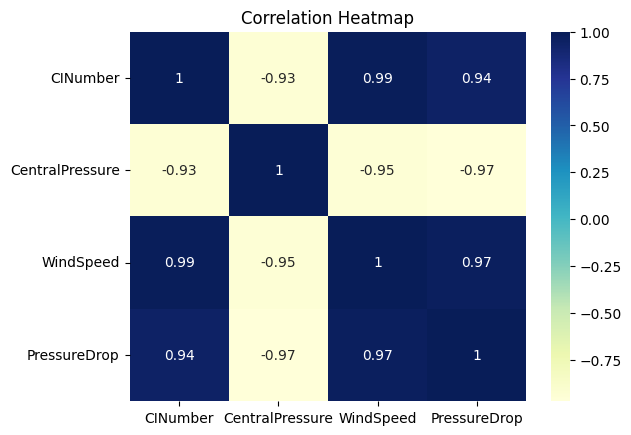

In [ ]:
dfc = df_2[['CINumber', 'CentralPressure', 'WindSpeed','PressureDrop']]
df_corr = dfc.corr()
sns.heatmap(df_corr, annot=True,cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()

<ipython-input-135-ecdbef744852>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



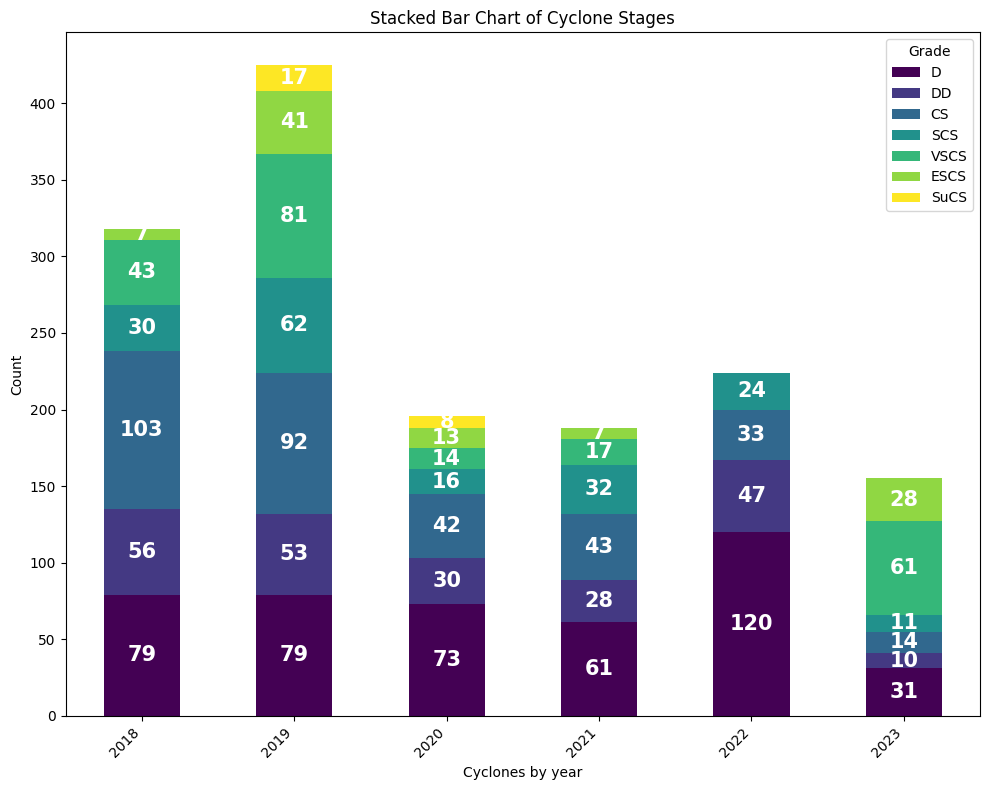

In [ ]:
stage_counts = df_1['Grade'].value_counts().reset_index()
stage_counts.columns = ['Stage', 'Count']
df_1['YEAR'] = df_1['Date'].dt.year
stage_counts_by_year = df_1.groupby('YEAR')['Grade'].value_counts().unstack(fill_value=0)
stage_counts_by_year = stage_counts_by_year[grade_order]
ax = stage_counts_by_year.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages')
plt.xlabel('Cyclones by year')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

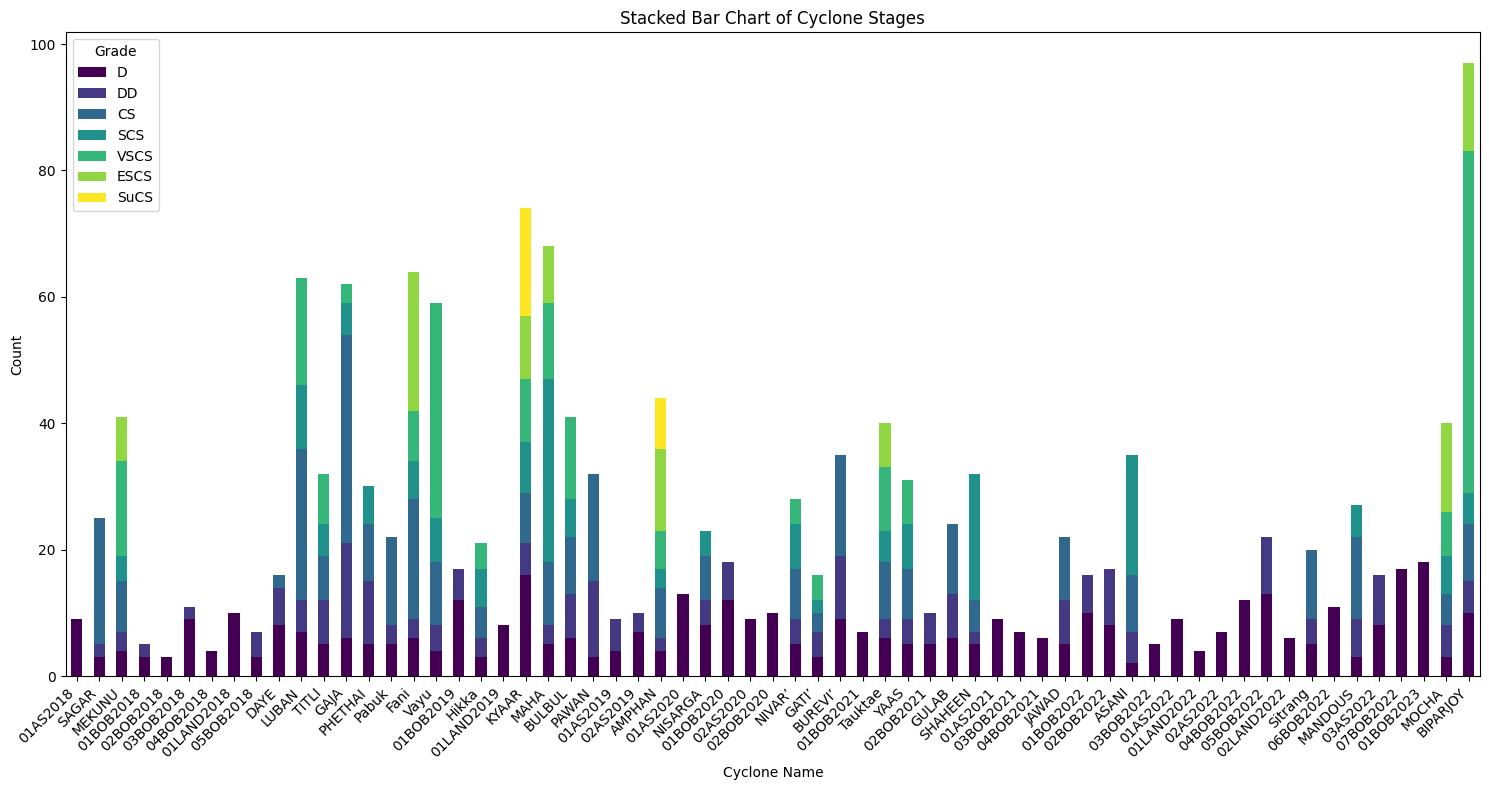

In [ ]:
stage_counts = df_1['Grade'].value_counts().reset_index()
stage_counts.columns = ['Stage', 'Count']
cyclone_stage_counts = df_1.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_1['Name'].unique()
cyclone_stage_counts = cyclone_stage_counts.reindex(original_order)
cyclone_stage_counts= cyclone_stage_counts[grade_order]
ax = cyclone_stage_counts.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='viridis')
plt.title('Stacked Bar Chart of Cyclone Stages')
plt.xlabel('Cyclone Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

<ipython-input-137-dbe900a0f8c2>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



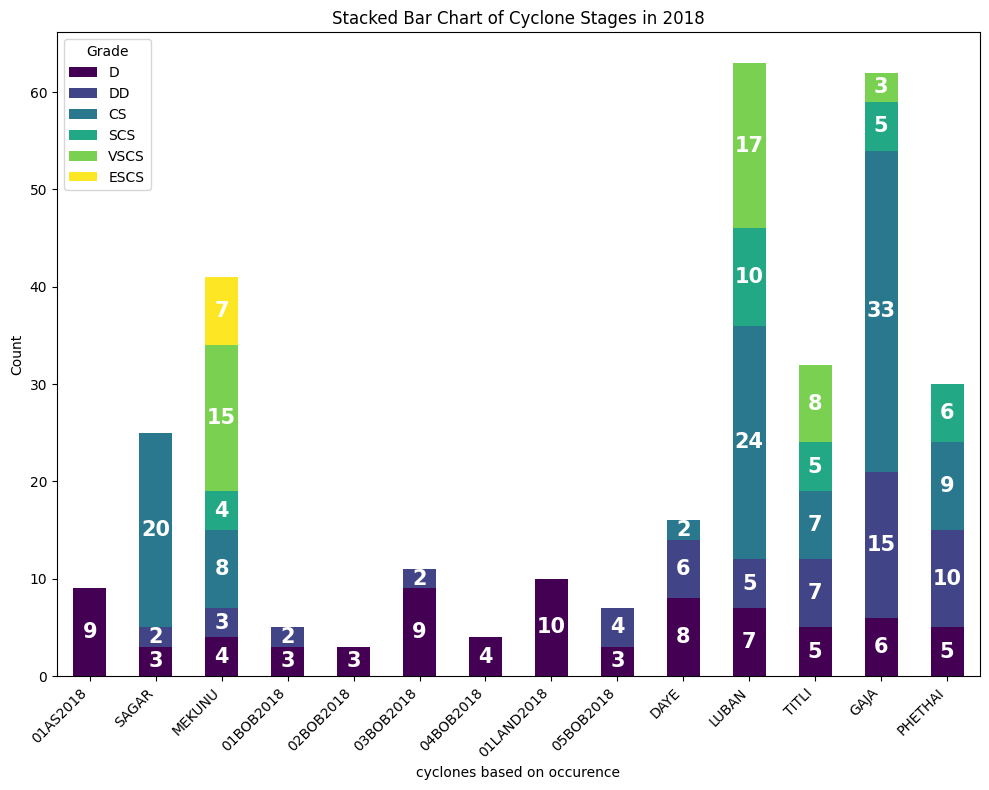

In [ ]:
df_1['YEAR'] = df_1['Date'].dt.year
df_2018 = df_1[df_1['YEAR'] == 2018]
cyclone_stage_counts_yearwise = df_2018.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_2018['Name'].unique()
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise.reindex(original_order)
cyclone_stage_counts_yearwise= cyclone_stage_counts_yearwise[grade_order_2]
ax = cyclone_stage_counts_yearwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages in 2018')
plt.xlabel('cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

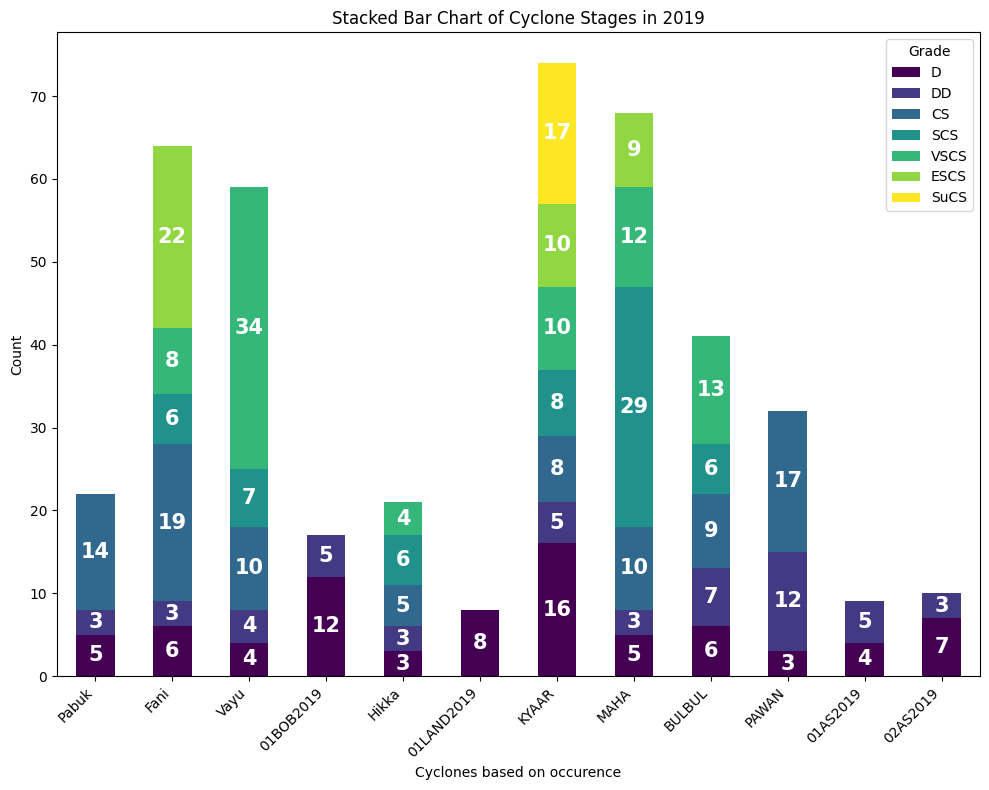

In [ ]:
df_2019 = df_1[df_1['YEAR'] == 2019]
cyclone_stage_counts_yearwise = df_2019.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_2019['Name'].unique()
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise.reindex(original_order)
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise[grade_order]
ax = cyclone_stage_counts_yearwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages in 2019')
plt.xlabel('Cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

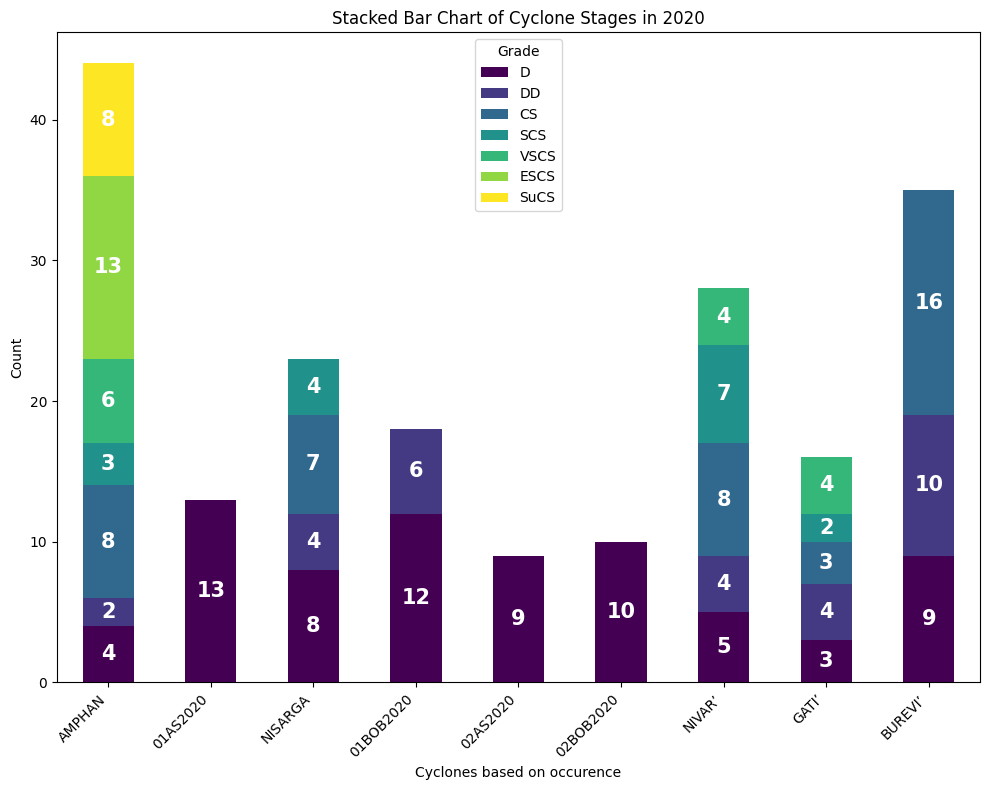

In [ ]:
df_2020 = df_1[df_1['YEAR'] == 2020]
cyclone_stage_counts_yearwise = df_2020.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_2020['Name'].unique()
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise.reindex(original_order)
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise[grade_order]
ax = cyclone_stage_counts_yearwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages in 2020')
plt.xlabel('Cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

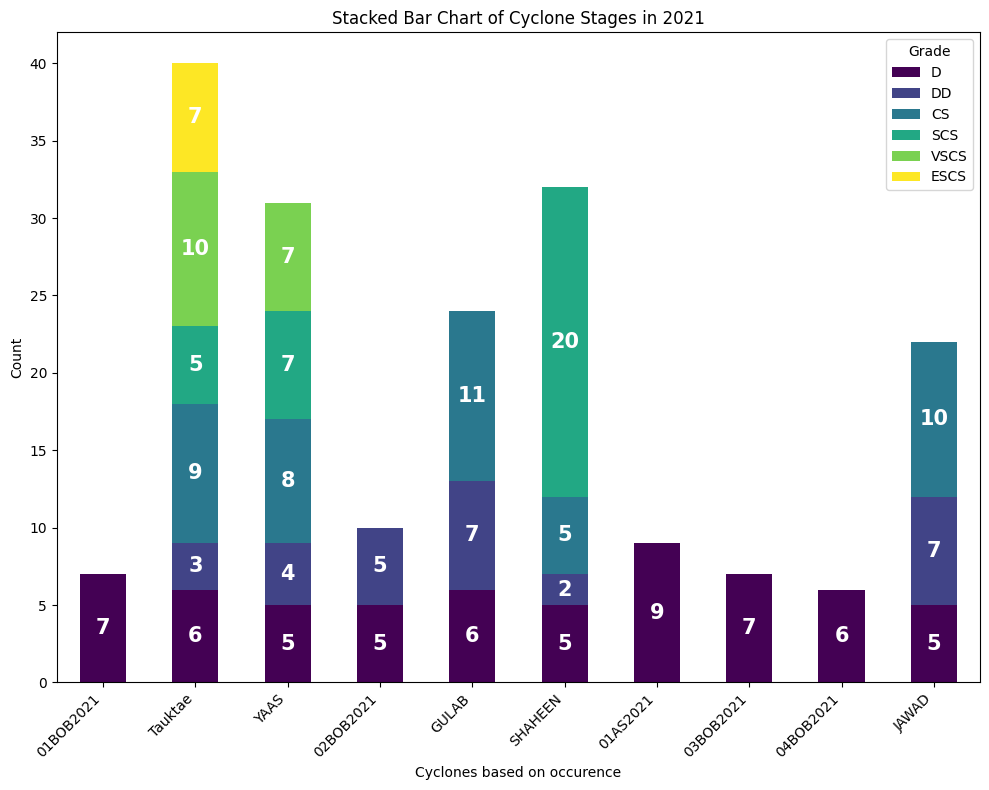

In [ ]:
df_2021 = df_1[df_1['YEAR'] == 2021]
cyclone_stage_counts_yearwise = df_2021.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_2021['Name'].unique()
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise.reindex(original_order)
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise[grade_order_2]
ax = cyclone_stage_counts_yearwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages in 2021')
plt.xlabel('Cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

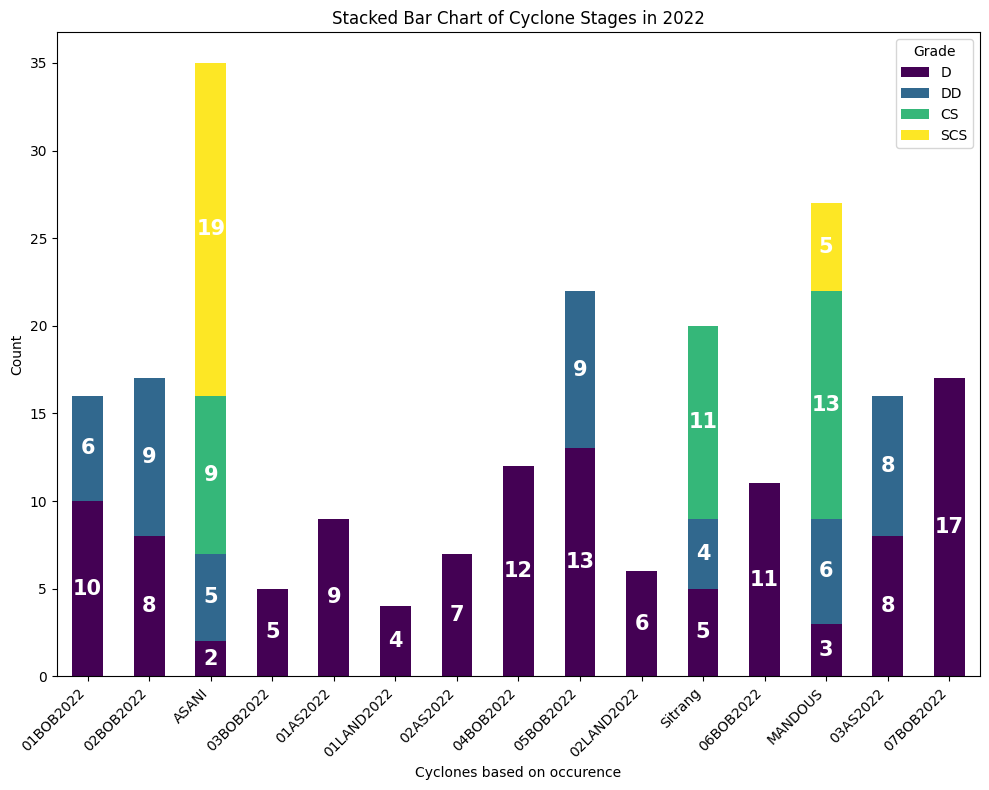

In [ ]:
df_2022 = df_1[df_1['YEAR'] == 2022]
cyclone_stage_counts_yearwise = df_2022.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_2022['Name'].unique()
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise.reindex(original_order)
original_grade_order = df_2022['Grade'].unique()
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise[original_grade_order]
ax = cyclone_stage_counts_yearwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages in 2022')
plt.xlabel('Cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

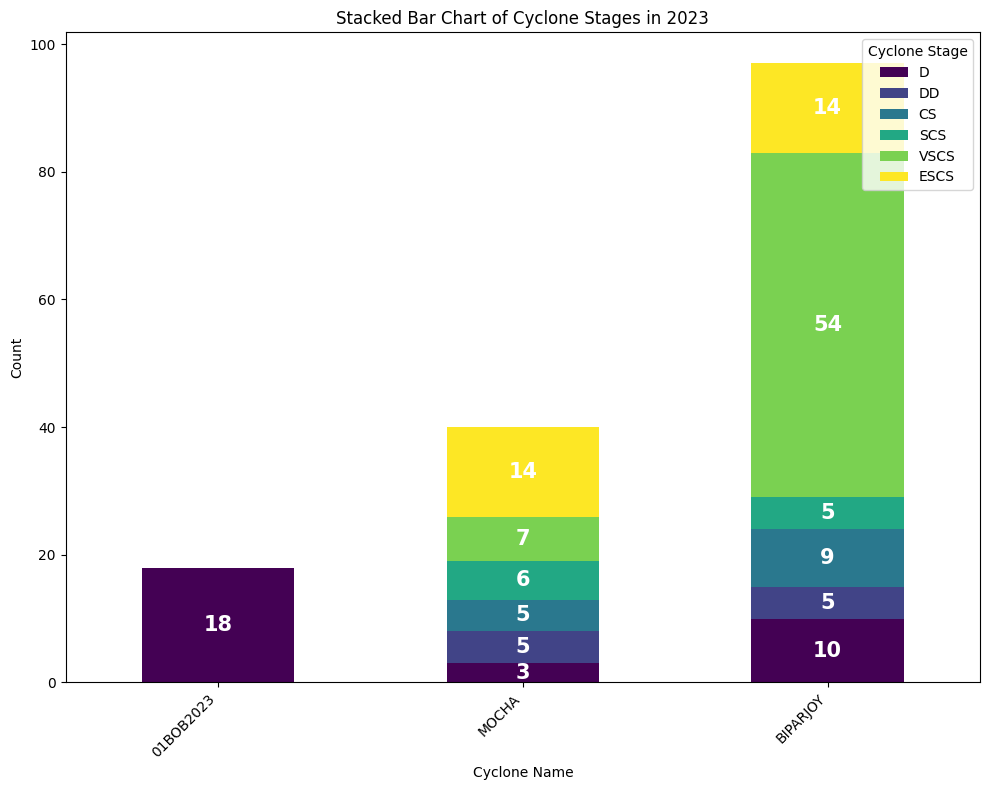

In [ ]:
df_2023 = df_1[df_1['YEAR'] == 2023]
cyclone_stage_counts_yearwise = df_2023.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_2023['Name'].unique()
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise.reindex(original_order)
original_grade_order = df_2023['Grade'].unique()
cyclone_stage_counts_yearwise = cyclone_stage_counts_yearwise[grade_order_2]
ax = cyclone_stage_counts_yearwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cyclone Stage', loc='upper right')
plt.title('Stacked Bar Chart of Cyclone Stages in 2023')
plt.xlabel('Cyclone Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

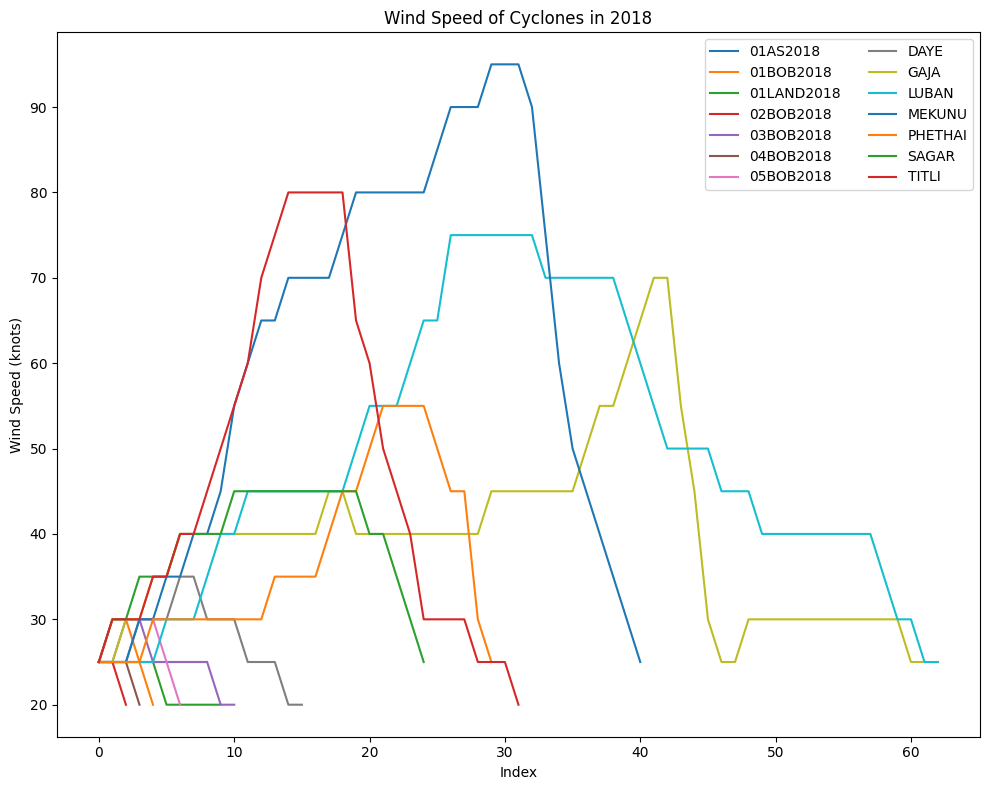

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for cyclone_name, data in df_2018.groupby('Name'):
    ax.plot(range(len(data)), data['WindSpeed'], label=cyclone_name)
ax.set_title('Wind Speed of Cyclones in 2018')
ax.set_ylabel('Wind Speed (knots)')
ax.set_xlabel('Index')
ax.legend(loc='best', ncol=2)

plt.tight_layout()
plt.show()

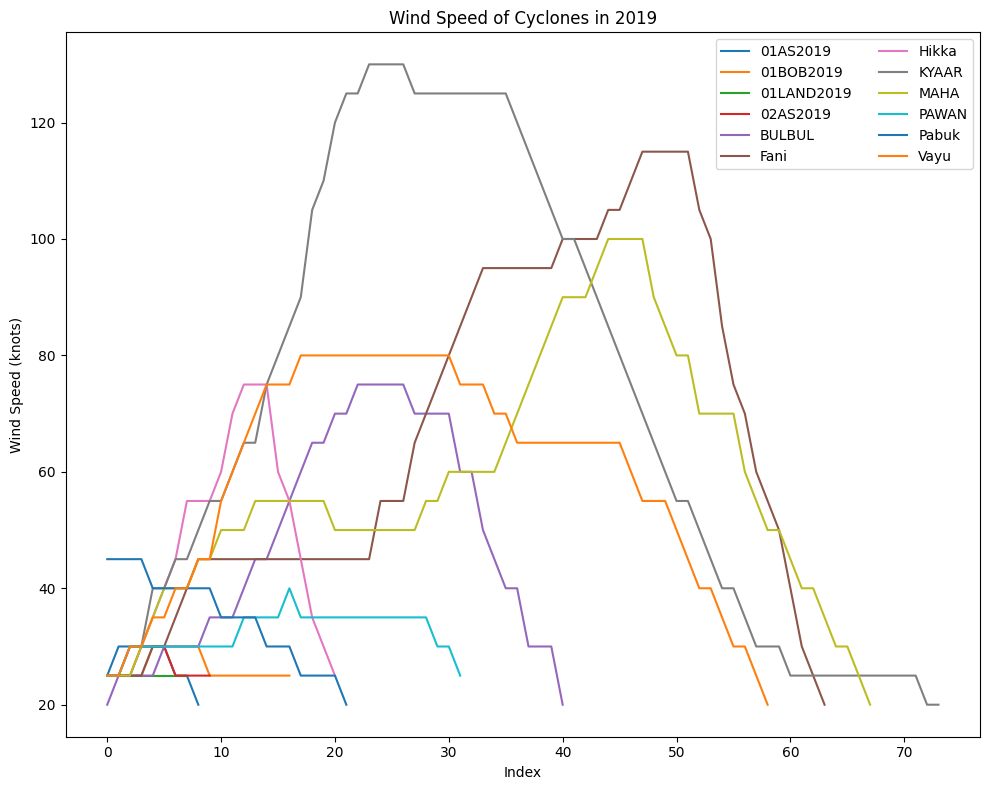

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for cyclone_name, data in df_2019.groupby('Name'):
    ax.plot(range(len(data)), data['WindSpeed'], label=cyclone_name)
ax.set_title('Wind Speed of Cyclones in 2019')
ax.set_ylabel('Wind Speed (knots)')
ax.set_xlabel('Index')
ax.legend(loc='best', ncol=2)

plt.tight_layout()
plt.show()

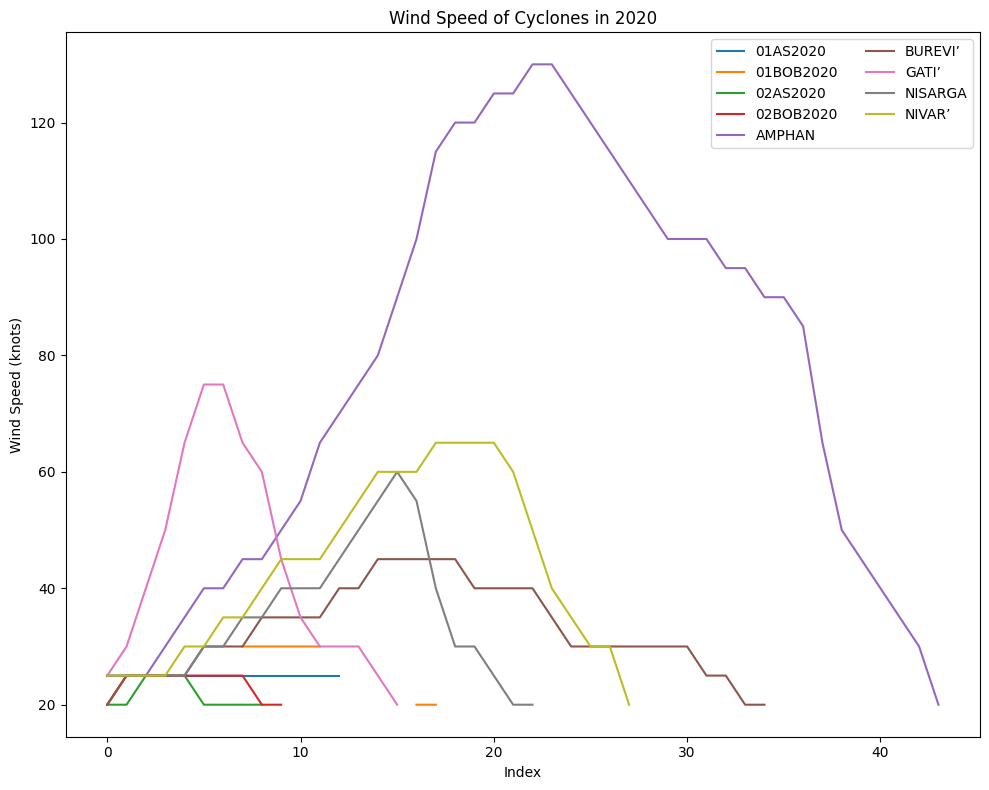

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for cyclone_name, data in df_2020.groupby('Name'):
    ax.plot(range(len(data)), data['WindSpeed'], label=cyclone_name)
ax.set_title('Wind Speed of Cyclones in 2020')
ax.set_ylabel('Wind Speed (knots)')
ax.set_xlabel('Index')
ax.legend(loc='best', ncol=2)

plt.tight_layout()
plt.show()

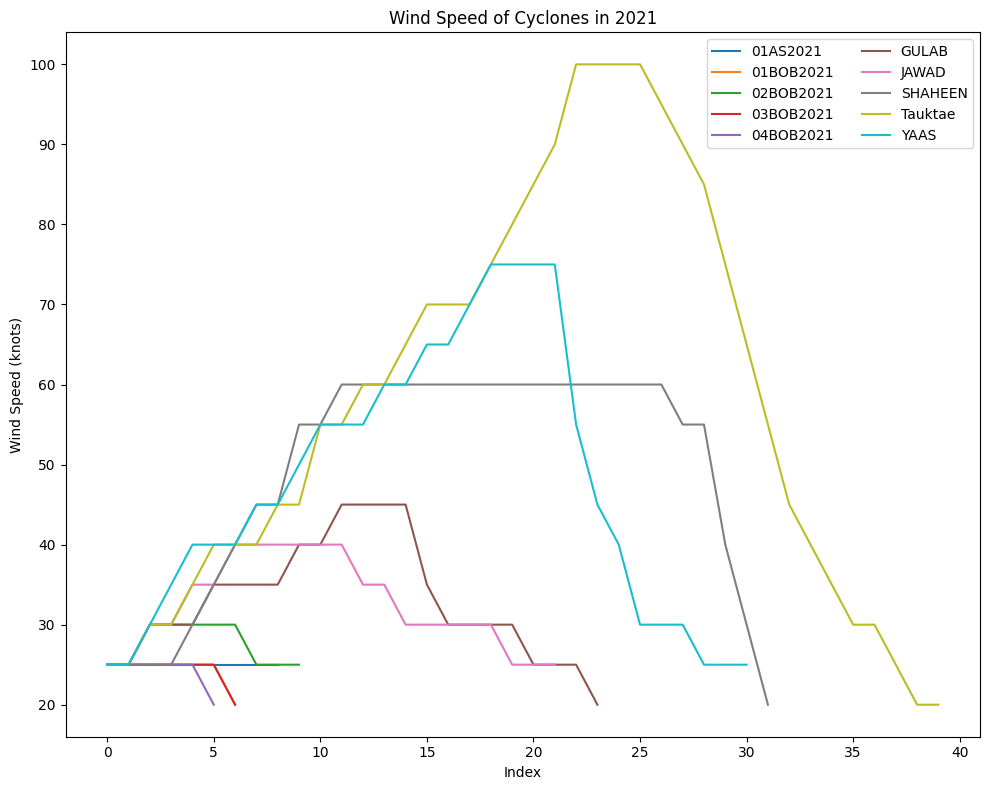

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for cyclone_name, data in df_2021.groupby('Name'):
    ax.plot(range(len(data)), data['WindSpeed'], label=cyclone_name)
ax.set_title('Wind Speed of Cyclones in 2021')
ax.set_ylabel('Wind Speed (knots)')
ax.set_xlabel('Index')
ax.legend(loc='best', ncol=2)

plt.tight_layout()
plt.show()

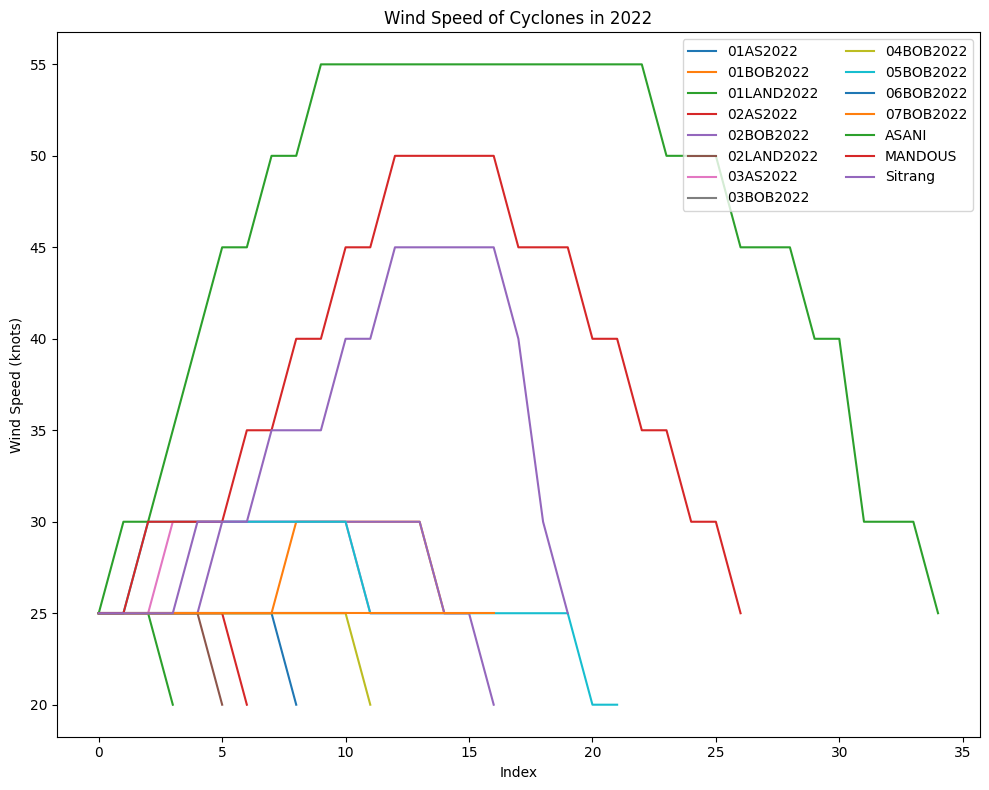

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for cyclone_name, data in df_2022.groupby('Name'):
    ax.plot(range(len(data)), data['WindSpeed'], label=cyclone_name)
ax.set_title('Wind Speed of Cyclones in 2022')
ax.set_ylabel('Wind Speed (knots)')
ax.set_xlabel('Index')
ax.legend(loc='best', ncol=2)

plt.tight_layout()
plt.show()

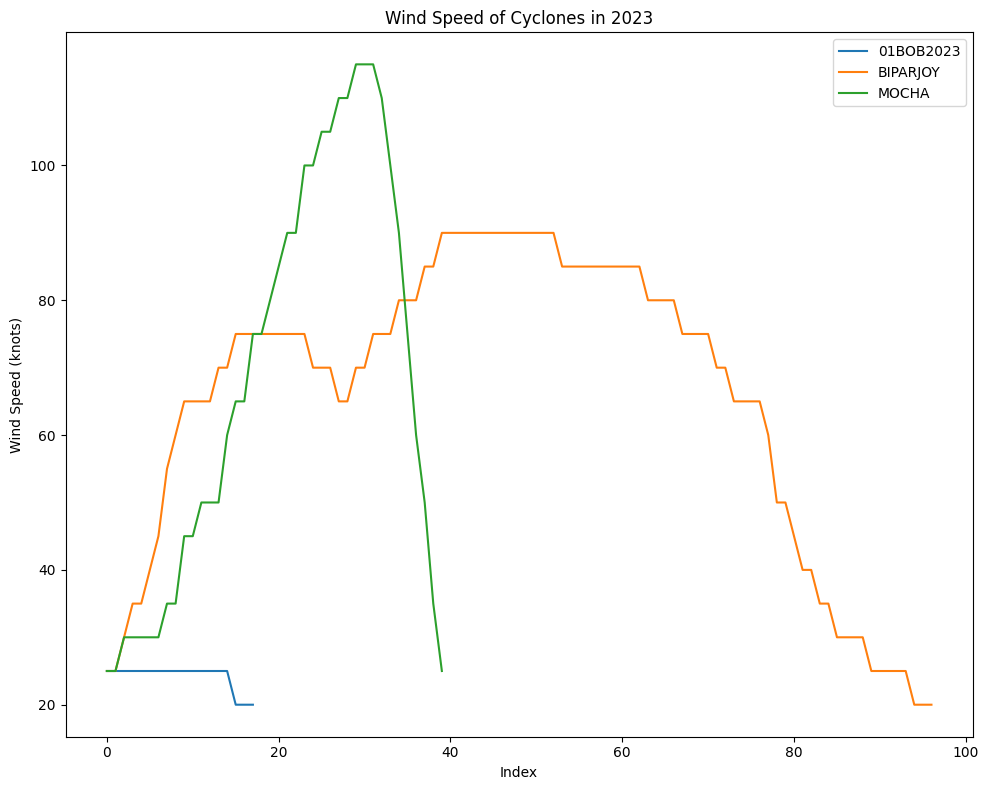

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for cyclone_name, data in df_2023.groupby('Name'):
    ax.plot(range(len(data)), data['WindSpeed'], label=cyclone_name)
ax.set_title('Wind Speed of Cyclones in 2023')
ax.set_ylabel('Wind Speed (knots)')
ax.set_xlabel('Index')
ax.legend(loc='best', ncol=1)

plt.tight_layout()
plt.show()

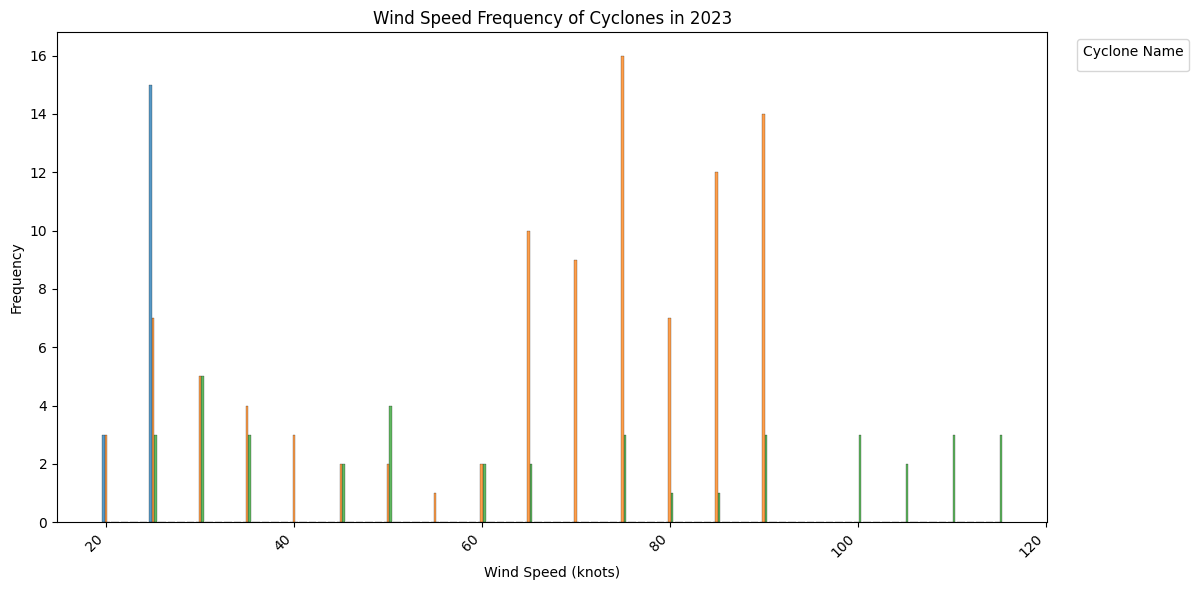

In [ ]:
# Calculate wind speed frequency for each cyclone
wind_speed_freq = df_2023.groupby('Name')['WindSpeed'].value_counts().reset_index(name='Frequency')

# Create the histogram plot
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.histplot(data=wind_speed_freq, x='WindSpeed', weights='Frequency', hue='Name',
             multiple="dodge", shrink=.8, discrete=True, common_bins=True) #common_bins added

# Customize the plot
plt.title('Wind Speed Frequency of Cyclones in 2023')
plt.xlabel('Wind Speed (knots)')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.legend(title='Cyclone Name', loc='upper right', bbox_to_anchor=(1.15, 1))  # Adjust legend placement
plt.tight_layout()
plt.show()

In [ ]:
df_1['Month'] = df_1['Date'].dt.month
df_1.tail()

,SerialNumber,Basin,Name,Date,TimeUTC,Latitude,Longitude,CINumber,CentralPressure,WindSpeed,PressureDrop,Grade,OL,YEAR,Month
1652,3.0,AS,BIPARJOY,2023-06-18,0300,26.2,73.8,NaN,992.0,25.0,3.0,D,L,2023,6
1653,3.0,AS,BIPARJOY,2023-06-18,0600,26.3,74.0,NaN,994.0,25.0,3.0,D,L,2023,6
1654,3.0,AS,BIPARJOY,2023-06-18,1200,26.3,74.7,NaN,995.0,20.0,3.0,D,L,2023,6
1655,3.0,AS,BIPARJOY,2023-06-18,1800,26.3,75.2,NaN,995.0,20.0,3.0,D,L,2023,6
1656,3.0,AS,BIPARJOY,2023-06-19,0000,26.3,76.0,NaN,995.0,20.0,3.0,D,L,2023,6


In [ ]:
df_1['Latitude'] = pd.to_numeric(df_1['Latitude'], errors='coerce').astype(float)

In [ ]:
df_1['Latitude'].dtype

dtype('float64')

In [ ]:
def categorize_monsoon(month):
    if month in [3, 4, 5]:
        return 'Pre-Monsoon'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    elif month in [9, 10, 11]:
        return 'Post-Monsoon'
    else:
        return 'Winter'

df_1['season'] = df_1['Month'].apply(categorize_monsoon)

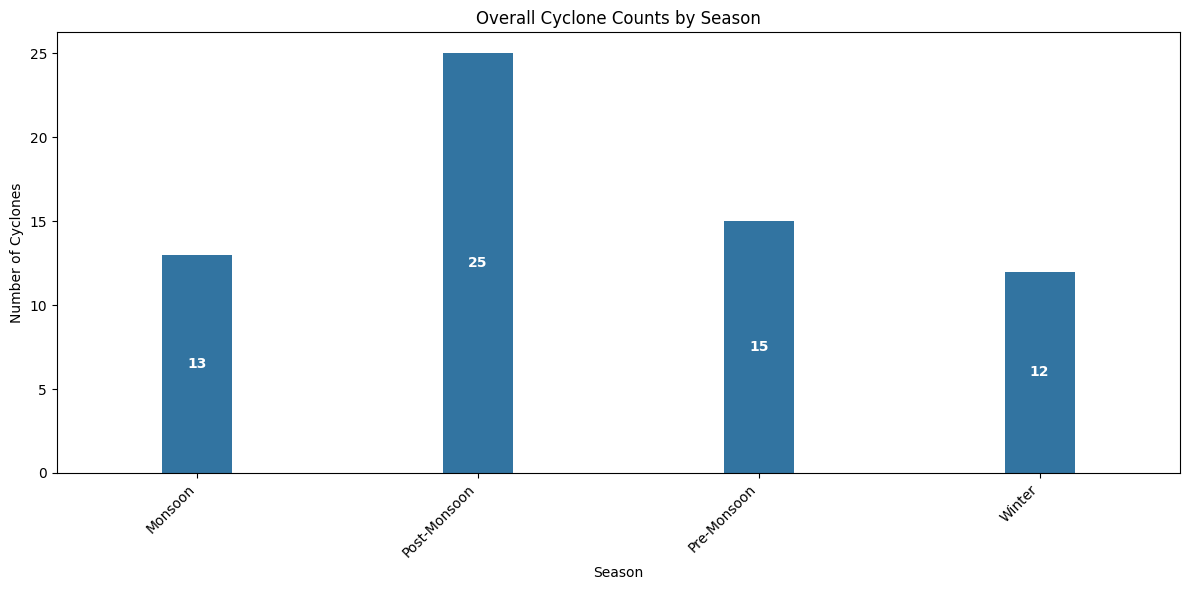

In [ ]:
season_counts = df_1.groupby('season')['Name'].nunique().reset_index(name='Cyclone_Count')
most_cyclones_season = season_counts.loc[season_counts['Cyclone_Count'].idxmax()]
season_month_counts = df_1.groupby(['season', 'Month'])['Name'].nunique().reset_index(name='Cyclone_Count')
most_cyclones_months = season_month_counts.loc[season_month_counts.groupby('season')['Cyclone_Count'].idxmax()]
plt.figure(figsize=(12, 6))
ax=sns.barplot(x='season', y='Cyclone_Count', data=season_counts,width=0.25)
for p in ax.patches:
      height = p.get_height()
      if height > 0:
        ax.annotate(
            format(height, '.0f'),
            (p.get_x() + p.get_width() / 2, p.get_y() + height / 2),
            ha='center', va='center', color='white', fontweight='bold', size=10
        )
plt.title('Overall Cyclone Counts by Season')
plt.xlabel('Season')
plt.ylabel('Number of Cyclones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

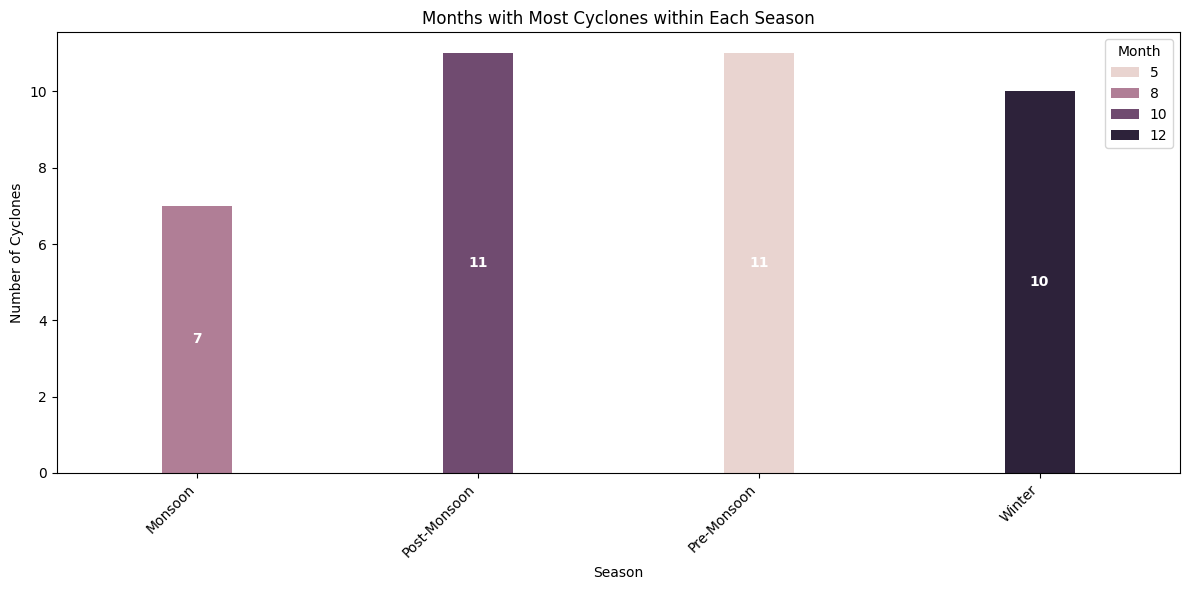

In [ ]:
plt.figure(figsize=(12, 6))
ax=sns.barplot(x='season', y='Cyclone_Count', hue='Month', data=most_cyclones_months,width=0.25)
for p in ax.patches:
      height = p.get_height()
      if height > 0:
        ax.annotate(
            format(height, '.0f'),
            (p.get_x() + p.get_width() / 2, p.get_y() + height / 2),
            ha='center', va='center', color='white', fontweight='bold', size=10
        )
plt.title('Months with Most Cyclones within Each Season')
plt.xlabel('Season')
plt.ylabel('Number of Cyclones')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Month', loc='upper right')
plt.tight_layout()
plt.show()

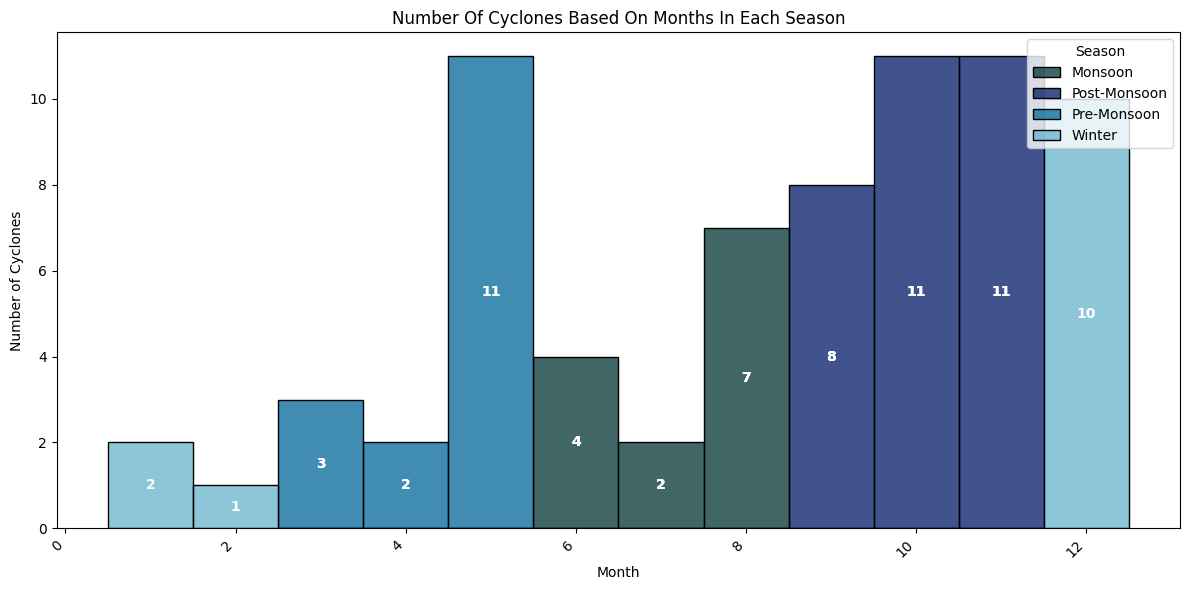

In [ ]:
season_month_counts = df_1.groupby(['season', 'Month'])['Name'].nunique().reset_index(name='Cyclone_Count')
all_months = list(range(1, 13))
plt.figure(figsize=(12, 6))
for i, season in enumerate(season_month_counts['season'].unique()):
    season_data = season_month_counts[season_month_counts['season'] == season]
    ax=sns.histplot(x='Month', weights='Cyclone_Count', data=season_data, discrete=True, label=season,
                 multiple="stack", color=sns.color_palette('ocean', len(season_month_counts['season'].unique()))[i])
    for p in ax.patches:
      height = p.get_height()
      if height > 0:
        ax.annotate(
            format(height, '.0f'),
            (p.get_x() + p.get_width() / 2, p.get_y() + height / 2),
            ha='center', va='center', color='white', fontweight='bold', size=10
        )
plt.title('Number Of Cyclones Based On Months In Each Season')
plt.xlabel('Month')
plt.ylabel('Number of Cyclones')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season', loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
df_monsoons = df_1[df_1['season'] == 'Monsoon']
df_pre_monsoons = df_1[df_1['season'] == 'Pre-Monsoon']
df_post_monsoons = df_1[df_1['season'] == 'Post-Monsoon']
df_winter = df_1[df_1['season'] == 'Winter']

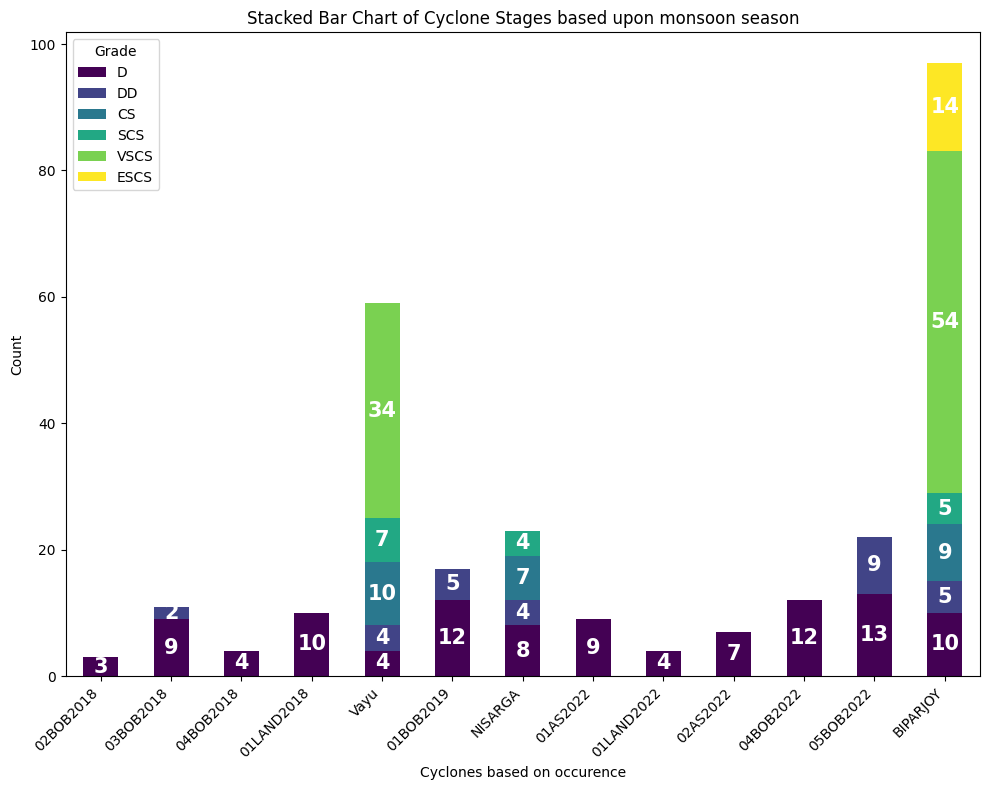

In [ ]:
cyclone_stage_counts_seasonwise = df_monsoons.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_monsoons['Name'].unique()
cyclone_stage_counts_seasonwise = cyclone_stage_counts_seasonwise.reindex(original_order)
cyclone_stage_counts_seasonwise = cyclone_stage_counts_seasonwise[grade_order_2]
ax = cyclone_stage_counts_seasonwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages based upon monsoon season')
plt.xlabel('Cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

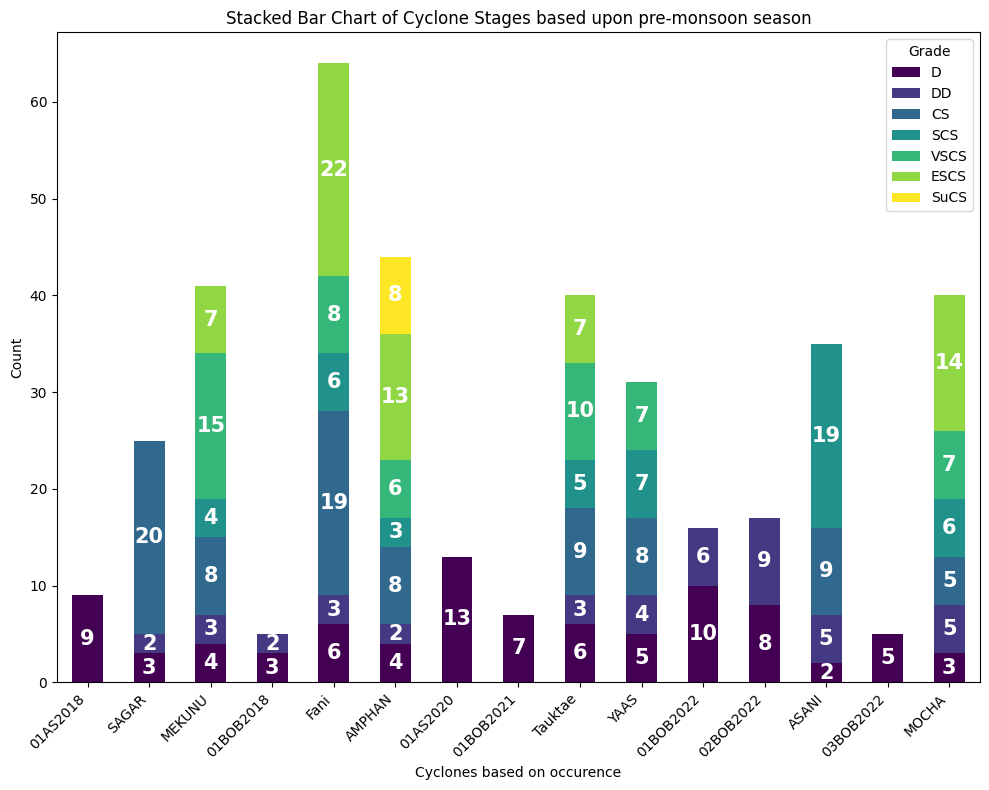

In [ ]:
cyclone_stage_counts_seasonwise = df_pre_monsoons.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_pre_monsoons['Name'].unique()
cyclone_stage_counts_seasonwise = cyclone_stage_counts_seasonwise.reindex(original_order)
cyclone_stage_counts_seasonwise = cyclone_stage_counts_seasonwise[grade_order]
ax = cyclone_stage_counts_seasonwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages based upon pre-monsoon season')
plt.xlabel('Cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

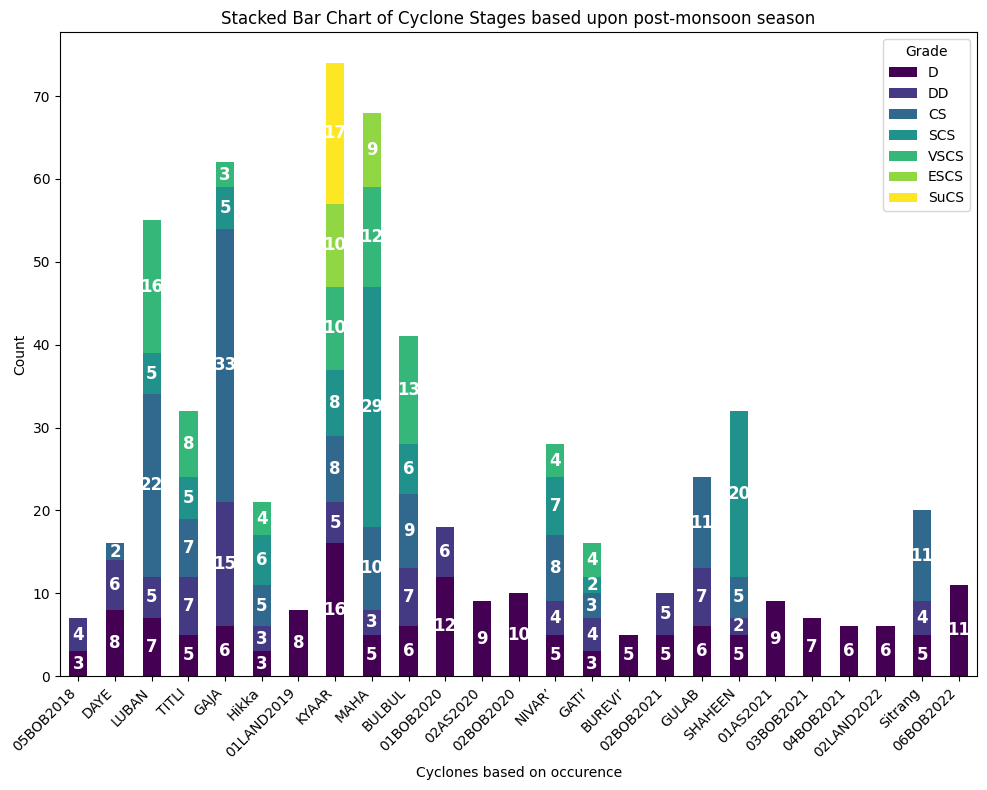

In [ ]:
cyclone_stage_counts_seasonwise = df_post_monsoons.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_post_monsoons['Name'].unique()
cyclone_stage_counts_seasonwise = cyclone_stage_counts_seasonwise.reindex(original_order)
cyclone_stage_counts_seasonwise = cyclone_stage_counts_seasonwise[grade_order]
ax = cyclone_stage_counts_seasonwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=12)
plt.title('Stacked Bar Chart of Cyclone Stages based upon post-monsoon season')
plt.xlabel('Cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

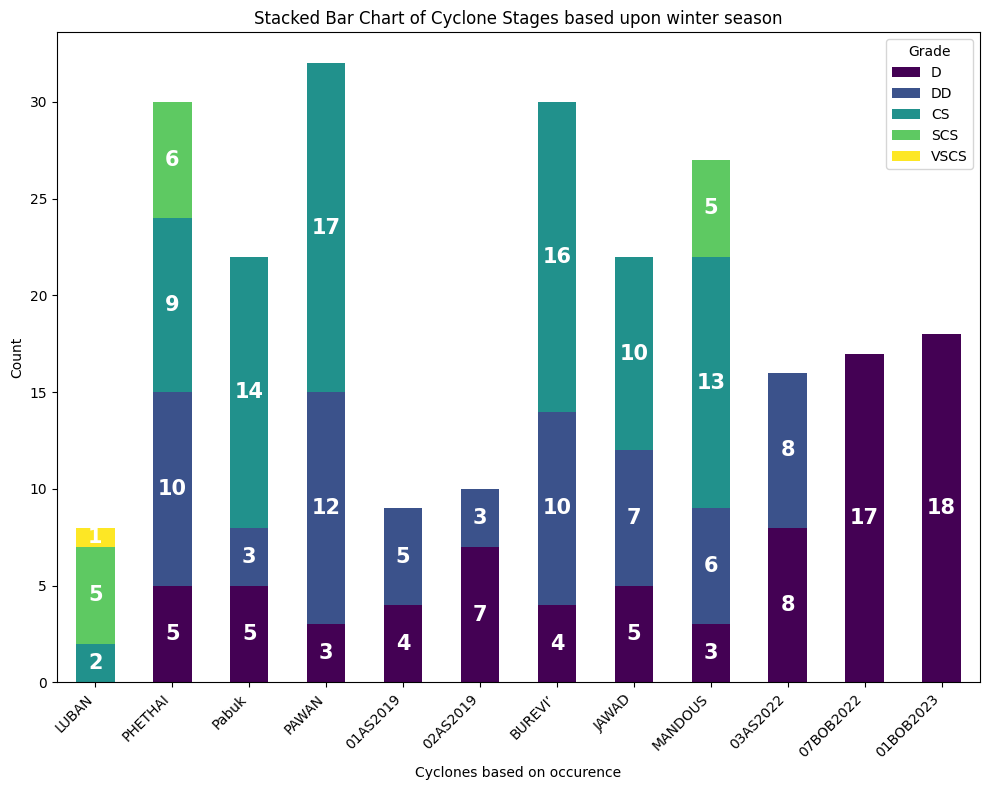

In [ ]:
cyclone_stage_counts_seasonwise = df_winter.groupby(['Name', 'Grade']).size().unstack(fill_value=0)
original_order = df_winter['Name'].unique()
cyclone_stage_counts_seasonwise = cyclone_stage_counts_seasonwise.reindex(original_order)
cyclone_stage_counts_seasonwise = cyclone_stage_counts_seasonwise[grade_order_3]
ax = cyclone_stage_counts_seasonwise.plot(kind='bar', stacked=True, figsize=(10, 8), colormap='viridis')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2,
                    int(height), ha='center', va='center', color='white', fontweight='bold',size=15)
plt.title('Stacked Bar Chart of Cyclone Stages based upon winter season')
plt.xlabel('Cyclones based on occurence')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [ ]:
import plotly.express as px
list_color = {'SuCS':'rgb(253, 231, 37)','ESCS':'rgb(144, 215, 67)','VSCS':'rgb(53, 183, 121)', 'SCS':'rgb(33, 145, 140)', 'CS':'rgb(49, 104, 142)', 'DD':'rgb(68, 57, 131)'
, 'D':'rgb(68, 1, 84)'}
fig = px.scatter_geo(
    df_1,
    lat='Latitude',
    lon='Longitude',
    color='Grade',  # Color points based on grade
    hover_name='Name',  # Display cyclone name on hover
    scope='world',  # Set map scope to the world
    title='Cyclone Tracks in last 5 years',
    color_discrete_map=list_color
)

# Customize map appearance (optional)
fig.update_geos(
    visible=True,  # Hide default map features
    resolution=110,  # Set map resolution
    showcountries=True,  # Show country borders
    countrycolor='lightgray',
    bgcolor="rgb(205,226,238)" # Set country border color
)

# Show the map
fig.show()

In [ ]:
import plotly.express as px
list_color = {'SuCS':'rgb(253, 231, 37)','ESCS':'rgb(144, 215, 67)','VSCS':'rgb(53, 183, 121)', 'SCS':'rgb(33, 145, 140)', 'CS':'rgb(49, 104, 142)', 'DD':'rgb(68, 57, 131)'
, 'D':'rgb(68, 1, 84)'}
fig = px.scatter_geo(
    df_2023,
    lat='Latitude',
    lon='Longitude',
    color='Grade',  # Color points based on grade
    hover_name='Name',  # Display cyclone name on hover
    scope='world',  # Set map scope to the world
    title='Cyclone Tracks in 2023',
    color_discrete_map=list_color
)

# Customize map appearance (optional)
fig.update_geos(
    visible=True,  # Hide default map features
    resolution=110,  # Set map resolution
    showcountries=True,  # Show country borders
    countrycolor='lightgray',
    bgcolor="rgb(205,226,238)" # Set country border color
)

# Show the map
fig.show()

In [ ]:
fig = px.scatter_geo(
    df_2022,
    lat='Latitude',
    lon='Longitude',
    color='Grade',  # Color points based on grade
    hover_name='Name',  # Display cyclone name on hover
    scope='world',  # Set map scope to the world
    title='Cyclone Tracks in 2022',
    color_discrete_map=list_color
)

# Customize map appearance (optional)
fig.update_geos(
    visible=True,  # Hide default map features
    resolution=110,  # Set map resolution
    showcountries=True,  # Show country borders
    countrycolor='lightgray',
    bgcolor="rgb(205,226,238)" # Set country border color
)

# Show the map
fig.show()

In [ ]:
fig = px.scatter_geo(
    df_2021,
    lat='Latitude',
    lon='Longitude',
    color='Grade',  # Color points based on grade
    hover_name='Name',  # Display cyclone name on hover
    scope='world',  # Set map scope to the world
    title='Cyclone Tracks in 2021',
    color_discrete_map=list_color
)

# Customize map appearance (optional)
fig.update_geos(
    visible=True,  # Hide default map features
    resolution=110,  # Set map resolution
    showcountries=True,  # Show country borders
    countrycolor='lightgray',
    bgcolor="rgb(205,226,238)" # Set country border color
)

# Show the map
fig.show()

In [ ]:
fig = px.scatter_geo(
    df_2020,
    lat='Latitude',
    lon='Longitude',
    color='Grade',  # Color points based on grade
    hover_name='Name',  # Display cyclone name on hover
    scope='world',  # Set map scope to the world
    title='Cyclone Tracks in 2020',
    color_discrete_map=list_color
)

# Customize map appearance (optional)
fig.update_geos(
    visible=True,  # Hide default map features
    resolution=110,  # Set map resolution
    showcountries=True,  # Show country borders
    countrycolor='lightgray',
    bgcolor="rgb(205,226,238)" # Set country border color
)

# Show the map
fig.show()

In [ ]:
fig = px.scatter_geo(
    df_2019,
    lat='Latitude',
    lon='Longitude',
    color='Grade',  # Color points based on grade
    hover_name='Name',  # Display cyclone name on hover
    scope='world',  # Set map scope to the world
    title='Cyclone Tracks in 2019',
    color_discrete_map=list_color
)

# Customize map appearance (optional)
fig.update_geos(
    visible=True,  # Hide default map features
    resolution=110,  # Set map resolution
    showcountries=True,  # Show country borders
    countrycolor='lightgray',
    bgcolor="rgb(205,226,238)" # Set country border color
)

# Show the map
fig.show()

In [ ]:
fig = px.scatter_geo(
    df_2018,
    lat='Latitude',
    lon='Longitude',
    color='Grade',  # Color points based on grade
    hover_name='Name',  # Display cyclone name on hover
    scope='world',  # Set map scope to the world
    title='Cyclone Tracks in 2018',
    color_discrete_map=list_color
)

# Customize map appearance (optional)
fig.update_geos(
    visible=True,  # Hide default map features
    resolution=110,  # Set map resolution
    showcountries=True,  # Show country borders
    countrycolor='lightgray',
    bgcolor="rgb(205,226,238)" # Set country border color
)

# Show the map
fig.show()

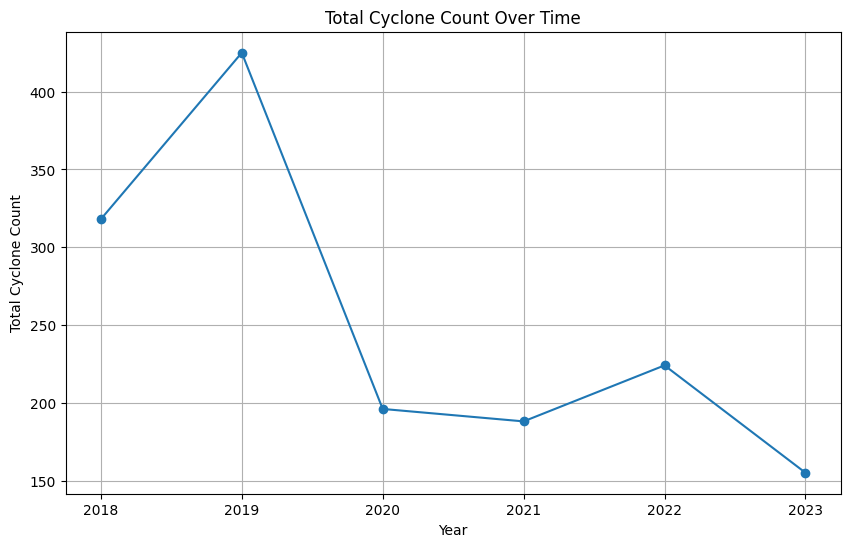

Interannual Variability (Standard Deviation): 101.69


In [ ]:
# Assuming 'stage_counts_by_year' is your DataFrame from earlier
import pandas as pd
import matplotlib.pyplot as plt

# Calculate total cyclone count per year
total_cyclones_per_year = stage_counts_by_year.sum(axis=1)

# Plot the total cyclone count over time
plt.figure(figsize=(10, 6))
plt.plot(total_cyclones_per_year.index, total_cyclones_per_year.values, marker='o')
plt.title('Total Cyclone Count Over Time')
plt.xlabel('Year')
plt.ylabel('Total Cyclone Count')
plt.grid(True)
plt.show()

# Calculate and print interannual variability (e.g., standard deviation)
interannual_variability = total_cyclones_per_year.std()
print(f"Interannual Variability (Standard Deviation): {interannual_variability:.2f}")

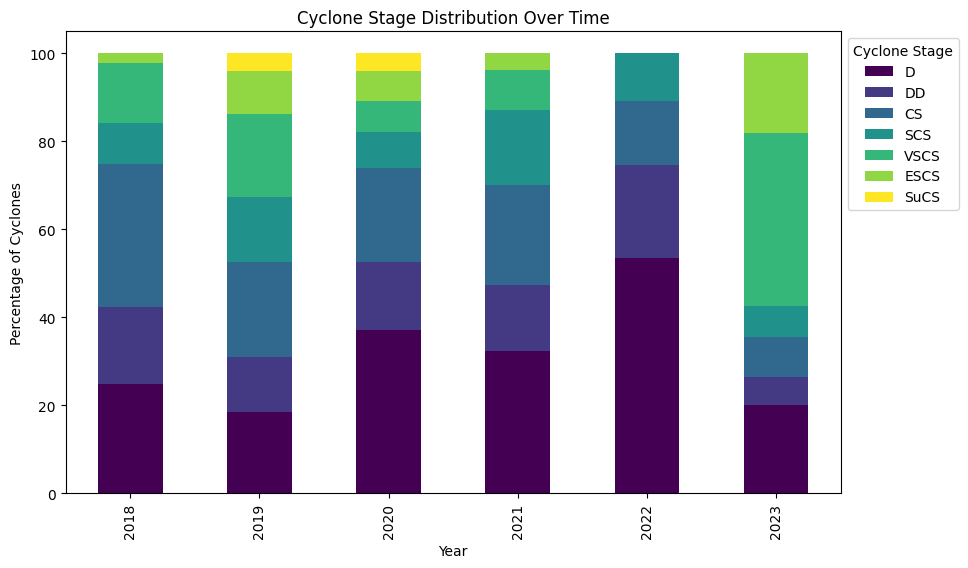

Percentage of SCS and above in 2020: 26.02%
Percentage of SCS and above in 2023: 64.52%


In [ ]:
# Calculate the percentage of each stage per year
stage_percentages = stage_counts_by_year.div(stage_counts_by_year.sum(axis=1), axis=0) * 100

# Plot the stage percentages over time
stage_percentages.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Cyclone Stage Distribution Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage of Cyclones')
plt.legend(title='Cyclone Stage', loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Analyze changes in stage percentages over time (e.g., compare specific years)
# Example: Compare the percentage of SCS and above in 2020 and 2023
scs_and_above_2020 = stage_percentages.loc[2020, ['SCS', 'VSCS', 'ESCS', 'SuCS']].sum()
scs_and_above_2023 = stage_percentages.loc[2023, ['SCS', 'VSCS', 'ESCS', 'SuCS']].sum()
print(f"Percentage of SCS and above in 2020: {scs_and_above_2020:.2f}%")
print(f"Percentage of SCS and above in 2023: {scs_and_above_2023:.2f}%")

In [ ]:
df_2

,SerialNumber,Basin,Name,Date,TimeUTC,Latitude,Longitude,CINumber,CentralPressure,WindSpeed,PressureDrop,Grade,OL,YEAR,Month,season
0,1.0,AS,01AS2018,2018-03-13,0300,5.0,76.0,1.0,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
1,1.0,AS,01AS2018,2018-03-13,0600,5.5,75.8,1.5,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
2,1.0,AS,01AS2018,2018-03-13,1200,6.5,75.0,1.5,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
3,1.0,AS,01AS2018,2018-03-13,1800,6.7,74.8,1.5,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
4,1.0,AS,01AS2018,2018-03-14,0000,7.0,74.5,1.5,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1652,3.0,AS,BIPARJOY,2023-06-18,0300,26.2,73.8,NaN,992.0,25.0,3.0,D,L,2023,6,Monsoon
1653,3.0,AS,BIPARJOY,2023-06-18,0600,26.3,74.0,NaN,994.0,25.0,3.0,D,L,2023,6,Monsoon
1654,3.0,AS,BIPARJOY,2023-06-18,1200,26.3,74.7,NaN,995.0,20.0,3.0,D,L,2023,6,Monsoon
1655,3.0,AS,BIPARJOY,2023-06-18,1800,26.3,75.2,NaN,995.0,20.0,3.0,D,L,2023,6,Monsoon


In [ ]:
df_3=df_2.drop(['Date','TimeUTC','Latitude','Longitude','SerialNumber'],axis=1)
df_3

,Basin,Name,CINumber,CentralPressure,WindSpeed,PressureDrop,Grade,OL,YEAR,Month,season
0,AS,01AS2018,1.0,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
1,AS,01AS2018,1.5,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
2,AS,01AS2018,1.5,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
3,AS,01AS2018,1.5,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
4,AS,01AS2018,1.5,1006.0,25.0,3.0,D,O,2018,3,Pre-Monsoon
...,...,...,...,...,...,...,...,...,...,...,...
1652,AS,BIPARJOY,NaN,992.0,25.0,3.0,D,L,2023,6,Monsoon
1653,AS,BIPARJOY,NaN,994.0,25.0,3.0,D,L,2023,6,Monsoon
1654,AS,BIPARJOY,NaN,995.0,20.0,3.0,D,L,2023,6,Monsoon
1655,AS,BIPARJOY,NaN,995.0,20.0,3.0,D,L,2023,6,Monsoon


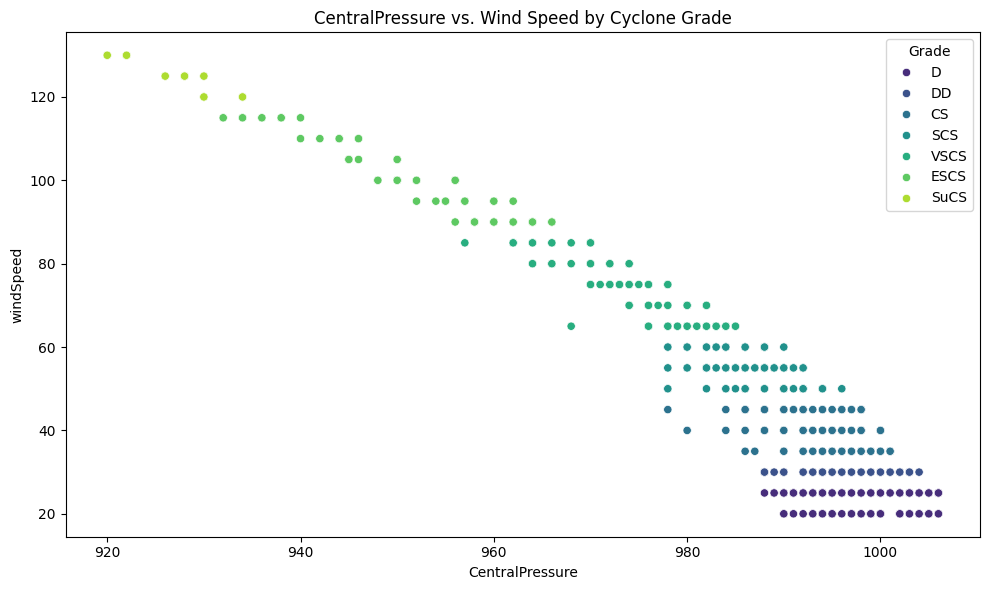

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CentralPressure', y='WindSpeed', hue='Grade', data=df_3, palette='viridis')
plt.title('CentralPressure vs. Wind Speed by Cyclone Grade')
plt.xlabel('CentralPressure')
plt.ylabel('windSpeed')
_ = plt.tight_layout()

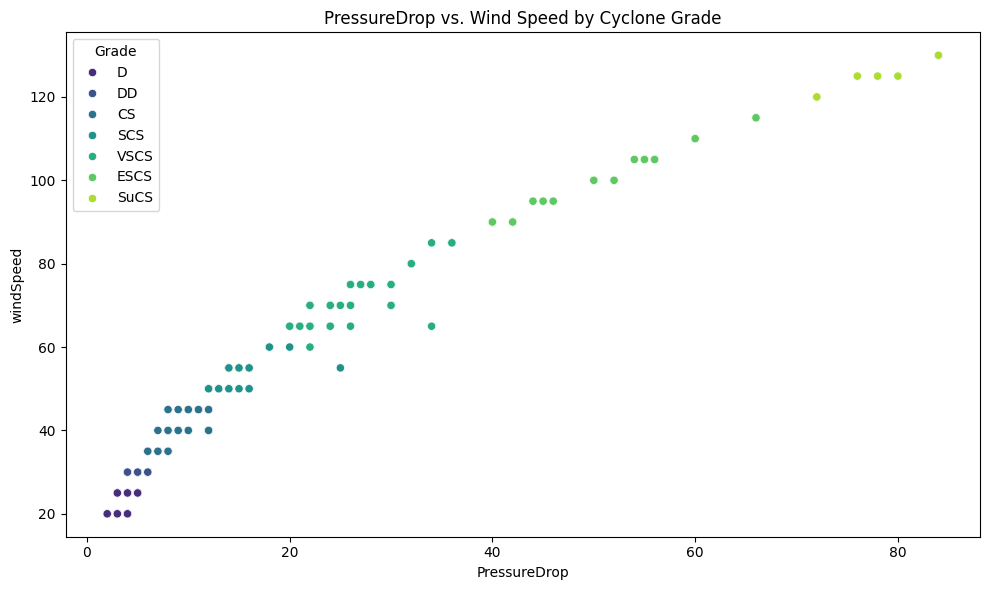

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PressureDrop', y='WindSpeed', hue='Grade', data=df_3, palette='viridis')
plt.title('PressureDrop vs. Wind Speed by Cyclone Grade')
plt.xlabel('PressureDrop')
plt.ylabel('windSpeed')
_ = plt.tight_layout()

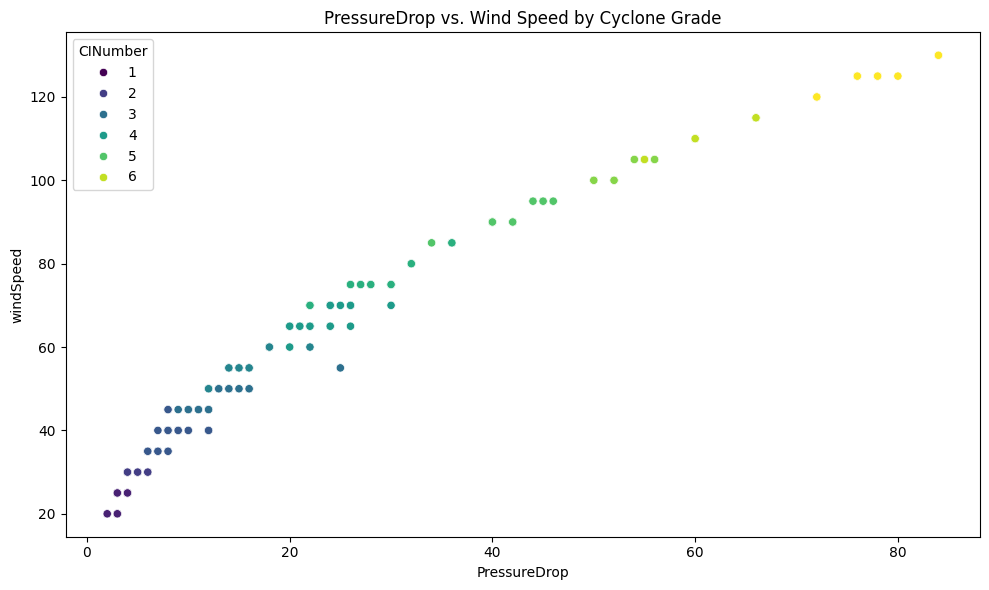

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PressureDrop', y='WindSpeed', hue='CINumber', data=df_3, palette='viridis')
plt.title('PressureDrop vs. Wind Speed by Cyclone Grade')
plt.xlabel('PressureDrop')
plt.ylabel('windSpeed')
_ = plt.tight_layout()

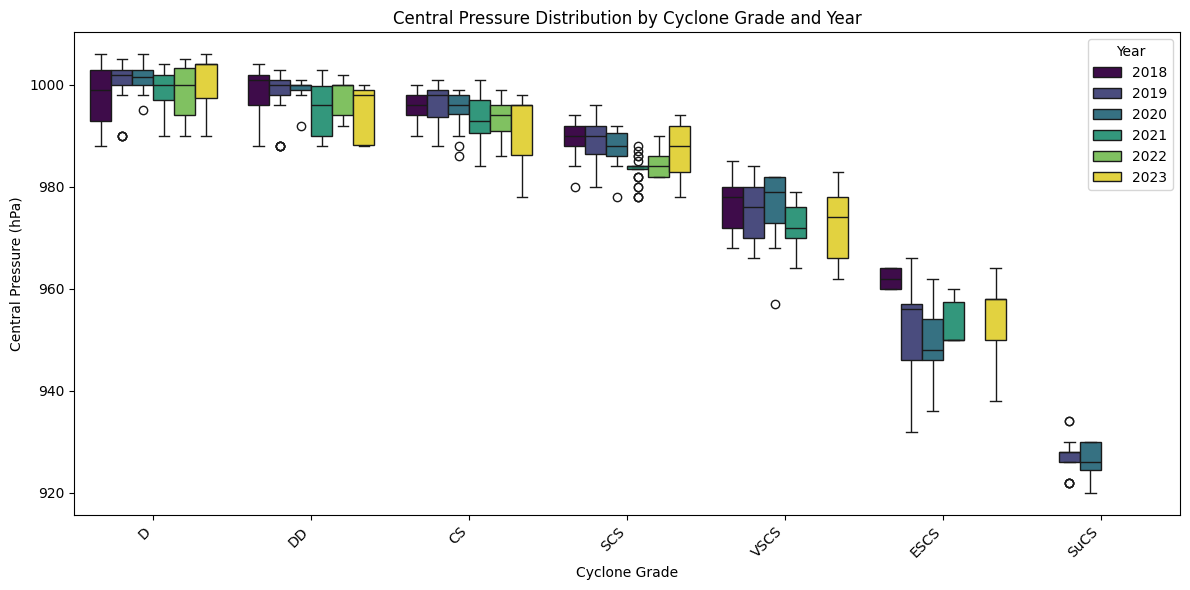

In [ ]:
# @title Central Pressure Distribution by Cyclone Grade and Year

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x='Grade', y='CentralPressure', hue='YEAR', data=df_3, palette='viridis')
plt.title('Central Pressure Distribution by Cyclone Grade and Year')
plt.xlabel('Cyclone Grade')
plt.ylabel('Central Pressure (hPa)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year', loc='upper right')
_ = plt.tight_layout()

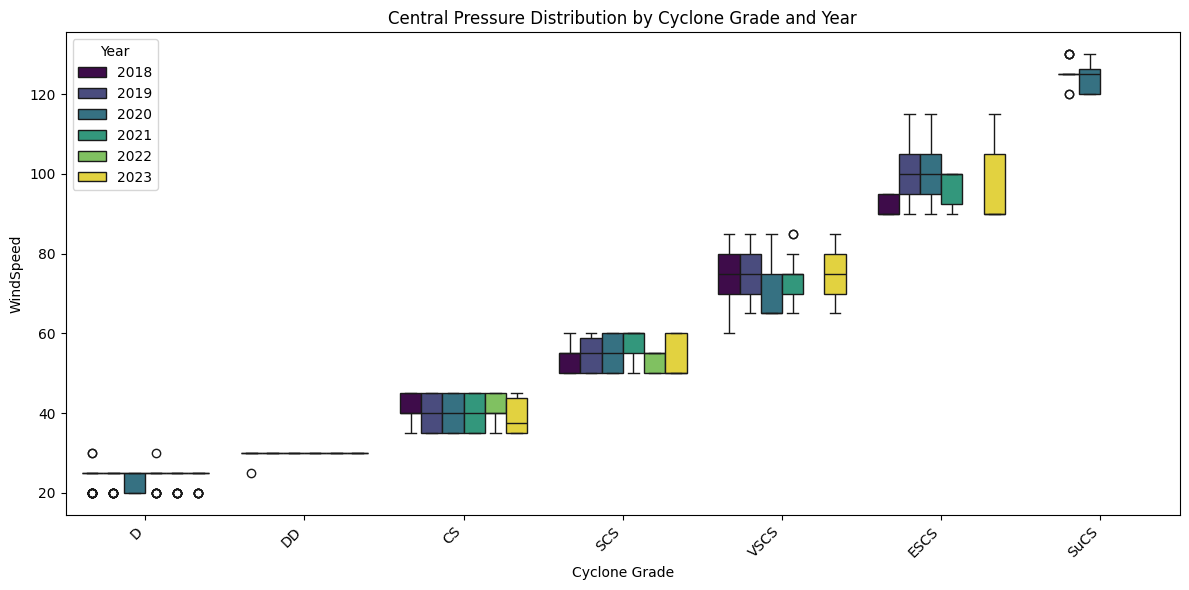

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Grade', y='WindSpeed', hue='YEAR', data=df_3, palette='viridis')
plt.title('Central Pressure Distribution by Cyclone Grade and Year')
plt.xlabel('Cyclone Grade')
plt.ylabel('WindSpeed')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year', loc='best')
_ = plt.tight_layout()

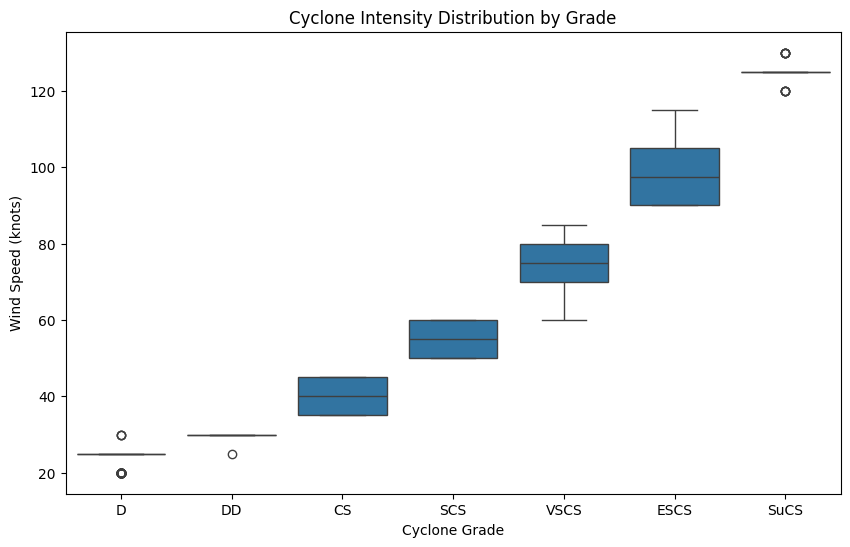

In [ ]:
# @title Cyclone Intensity Distribution by Grade

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Grade', y='WindSpeed', data=df_3)
plt.title('Cyclone Intensity Distribution by Grade')
plt.xlabel('Cyclone Grade')
_ = plt.ylabel('Wind Speed (knots)')

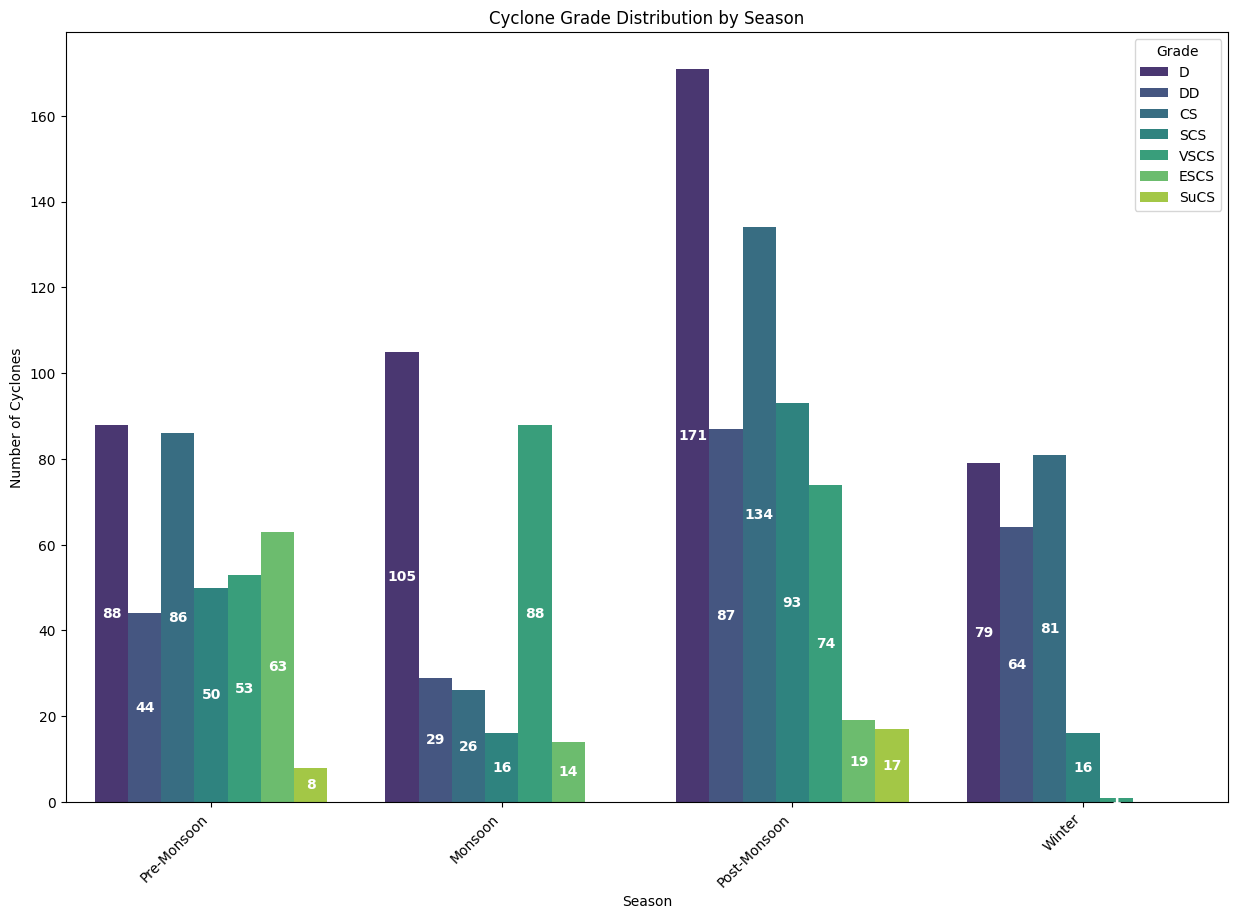

In [ ]:
# @title Cyclone Grade Distribution by Season

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
ax=sns.countplot(x='season', hue='Grade', data=df_3,palette='viridis')
for p in ax.patches:
      height = p.get_height()
      if height > 0:
        ax.annotate(
            format(height, '.0f'),
            (p.get_x() + p.get_width() / 2, p.get_y() + height / 2),
            ha='center', va='center', color='white', fontweight='bold', size=10
        )
plt.title('Cyclone Grade Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Number of Cyclones')
_ = plt.xticks(rotation=45, ha='right')

<ipython-input-180-63f1cbad90bc>:5: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

/usr/local/lib/python3.10/dist-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".

/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip

/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip

/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip

/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning

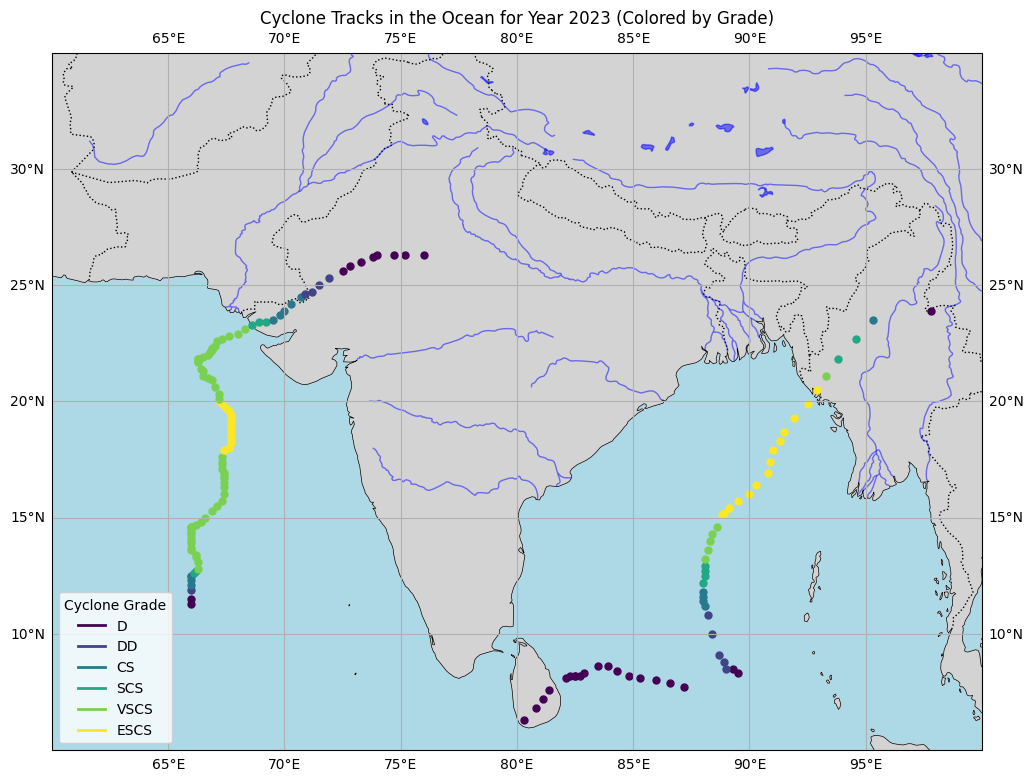

In [ ]:

# Load the cyclone data into a DataFrame
# df_2023 = pd.read_csv('cyclone_data_2023.csv') # Uncomment if loading from CSV

# Grade-wise colors
cmap = cm.get_cmap('viridis', len(grade_order_2))  # Create colormap

# Create color dictionary based on the 'viridis' colormap
grade_colors = {grade: cmap(i) for i, grade in enumerate(grade_order_2)}

# Initialize map
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.LAKES, color="blue", alpha=0.5)
ax.add_feature(cfeature.RIVERS, color="blue",alpha=0.5)

# Get unique cyclone names
unique_cyclones = df_2023['Name'].unique()

# Plot tracks with color grading
for cyclone_name in unique_cyclones:
    cyclone_data = df_2023[df_2023['Name'] == cyclone_name]
    for _, row in cyclone_data.iterrows():
        grade = row['Grade']
        color = grade_colors.get(grade, 'gray')  # Default to gray if grade is missing
        plt.plot(row['Longitude'], row['Latitude'],
                 color=color, marker='o', markersize=5, linewidth=2,
                 transform=ccrs.PlateCarree())

# Add gridlines and title
plt.title("Cyclone Tracks in the Ocean for Year 2023 (Colored by Grade)")
ax.gridlines(draw_labels=True)

# Add legend for grades
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=2, label=grade)
                   for grade, color in grade_colors.items()]
plt.legend(handles=legend_elements, loc='lower left', title="Cyclone Grade")

# Map extent
ax.set_extent([60, 100, 5, 35], crs=ccrs.PlateCarree())

plt.show()


<ipython-input-181-9e1ff1a04404>:1: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

/usr/local/lib/python3.10/dist-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



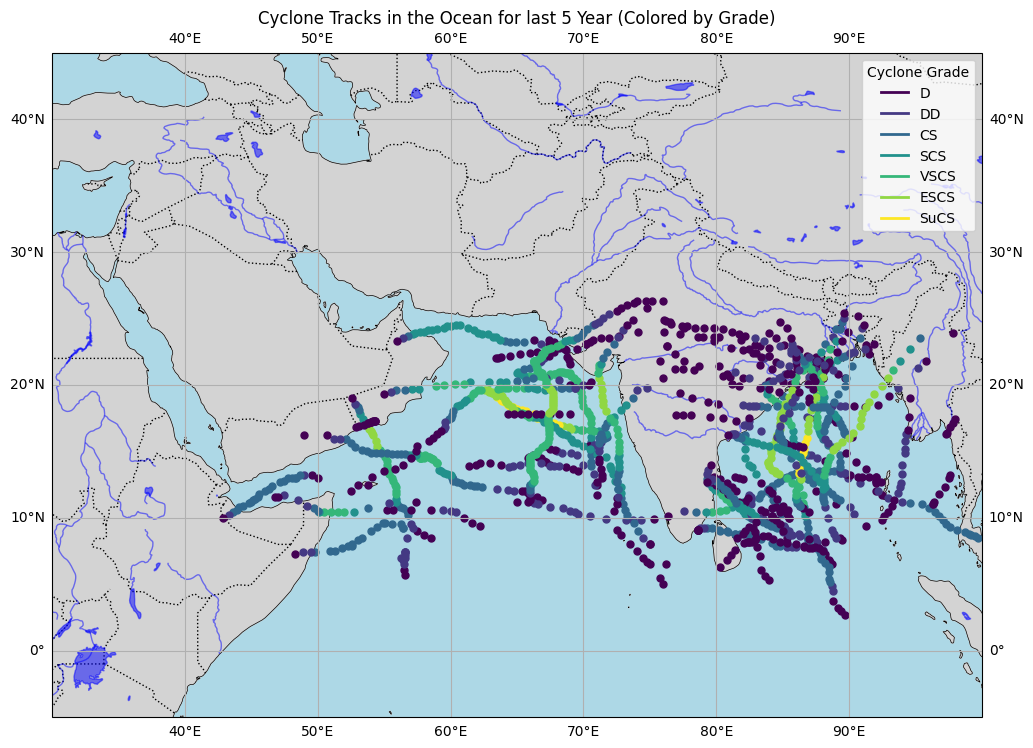

In [ ]:
cmap = cm.get_cmap('viridis', len(grade_order))  # Create colormap

# Create color dictionary based on the 'viridis' colormap
grade_colors = {grade: cmap(i) for i, grade in enumerate(grade_order)}

# Initialize map
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.LAKES, color="blue", alpha=0.5)
ax.add_feature(cfeature.RIVERS, color="blue",alpha=0.5)

# Get unique cyclone names
unique_cyclones = df_1['Name'].unique()

# Plot tracks with color grading
for cyclone_name in unique_cyclones:
    cyclone_data = df_1[df_1['Name'] == cyclone_name]
    for _, row in cyclone_data.iterrows():
        grade = row['Grade']
        color = grade_colors.get(grade, 'gray')  # Default to gray if grade is missing
        plt.plot(row['Longitude'], row['Latitude'],
                 color=color, marker='o', markersize=5, linewidth=2, linestyle='-',
                 transform=ccrs.PlateCarree())

# Add gridlines and title
plt.title("Cyclone Tracks in the Ocean for last 5 Year (Colored by Grade)")
ax.gridlines(draw_labels=True)

# Add legend for grades
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=2, label=grade)
                   for grade, color in grade_colors.items()]
plt.legend(handles=legend_elements, loc='best', title="Cyclone Grade")

# Map extent
ax.set_extent([30, 100, -5, 45], crs=ccrs.PlateCarree())

plt.show()


<ipython-input-182-ec58b9792a0b>:1: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

/usr/local/lib/python3.10/dist-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



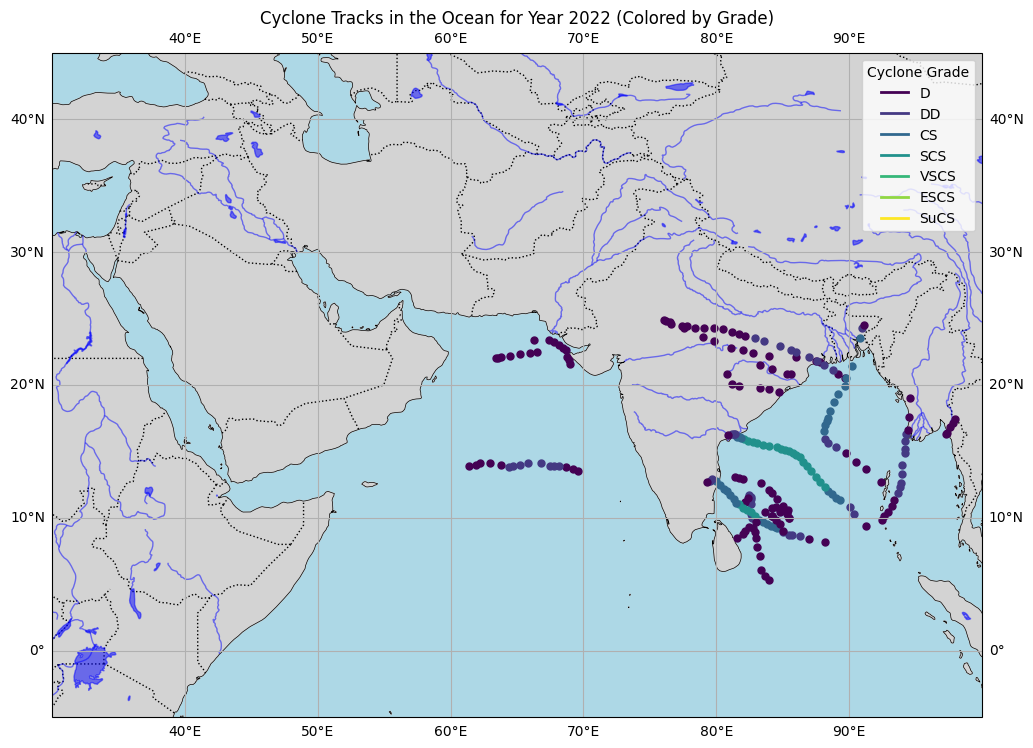

In [ ]:
cmap = cm.get_cmap('viridis', len(grade_order))  # Create colormap

# Create color dictionary based on the 'viridis' colormap
grade_colors = {grade: cmap(i) for i, grade in enumerate(grade_order)}

# Initialize map
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.LAKES, color="blue", alpha=0.5)
ax.add_feature(cfeature.RIVERS, color="blue",alpha=0.5)

# Get unique cyclone names
unique_cyclones = df_2022['Name'].unique()

# Plot tracks with color grading
for cyclone_name in unique_cyclones:
    cyclone_data = df_2022[df_2022['Name'] == cyclone_name]
    for _, row in cyclone_data.iterrows():
        grade = row['Grade']
        color = grade_colors.get(grade, 'gray')  # Default to gray if grade is missing
        plt.plot(row['Longitude'], row['Latitude'],
                 color=color, marker='o', markersize=5, linewidth=2, linestyle='-',
                 transform=ccrs.PlateCarree())

# Add gridlines and title
plt.title("Cyclone Tracks in the Ocean for Year 2022 (Colored by Grade)")
ax.gridlines(draw_labels=True)

# Add legend for grades
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=2, label=grade)
                   for grade, color in grade_colors.items()]
plt.legend(handles=legend_elements, loc='best', title="Cyclone Grade")

# Map extent
ax.set_extent([30, 100, -5, 45], crs=ccrs.PlateCarree())

plt.show()


<ipython-input-183-3d3efc929751>:1: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

/usr/local/lib/python3.10/dist-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



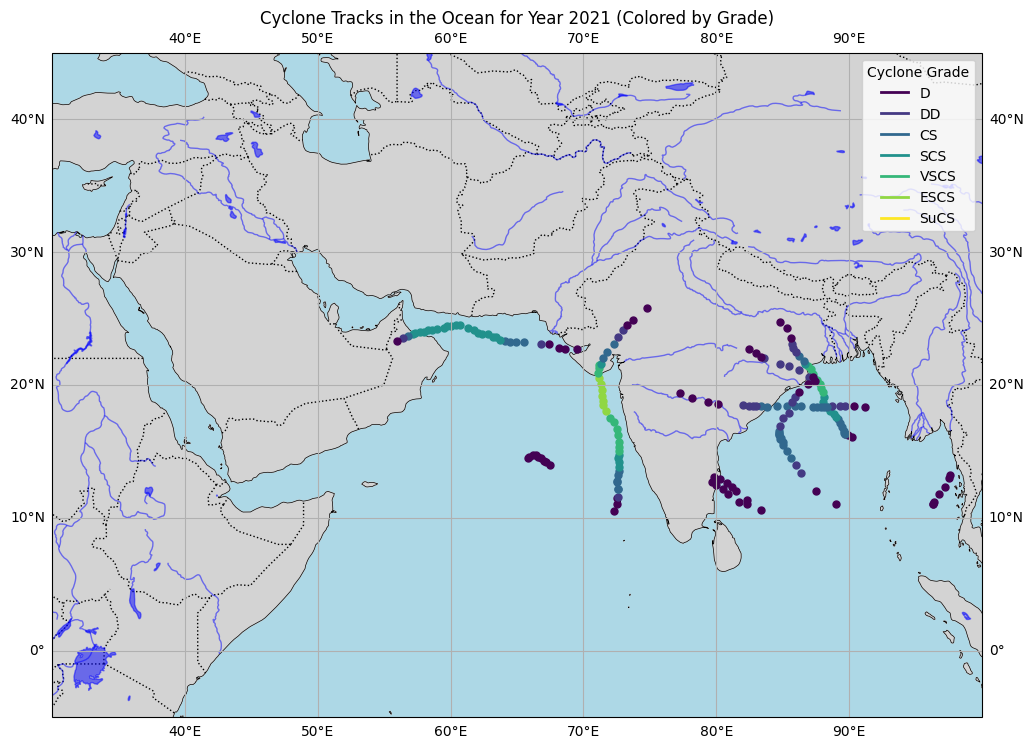

In [ ]:
cmap = cm.get_cmap('viridis', len(grade_order))  # Create colormap

# Create color dictionary based on the 'viridis' colormap
grade_colors = {grade: cmap(i) for i, grade in enumerate(grade_order)}

# Initialize map
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.LAKES, color="blue", alpha=0.5)
ax.add_feature(cfeature.RIVERS, color="blue",alpha=0.5)

# Get unique cyclone names
unique_cyclones = df_2021['Name'].unique()

# Plot tracks with color grading
for cyclone_name in unique_cyclones:
    cyclone_data = df_2021[df_2021['Name'] == cyclone_name]
    for _, row in cyclone_data.iterrows():
        grade = row['Grade']
        color = grade_colors.get(grade, 'gray')  # Default to gray if grade is missing
        plt.plot(row['Longitude'], row['Latitude'],
                 color=color, marker='o', markersize=5, linewidth=2, linestyle='-',
                 transform=ccrs.PlateCarree())

# Add gridlines and title
plt.title("Cyclone Tracks in the Ocean for Year 2021 (Colored by Grade)")
ax.gridlines(draw_labels=True)

# Add legend for grades
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=2, label=grade)
                   for grade, color in grade_colors.items()]
plt.legend(handles=legend_elements, loc='best', title="Cyclone Grade")

# Map extent
ax.set_extent([30, 100, -5, 45], crs=ccrs.PlateCarree())

plt.show()


<ipython-input-184-eed5c72b4b68>:1: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

/usr/local/lib/python3.10/dist-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



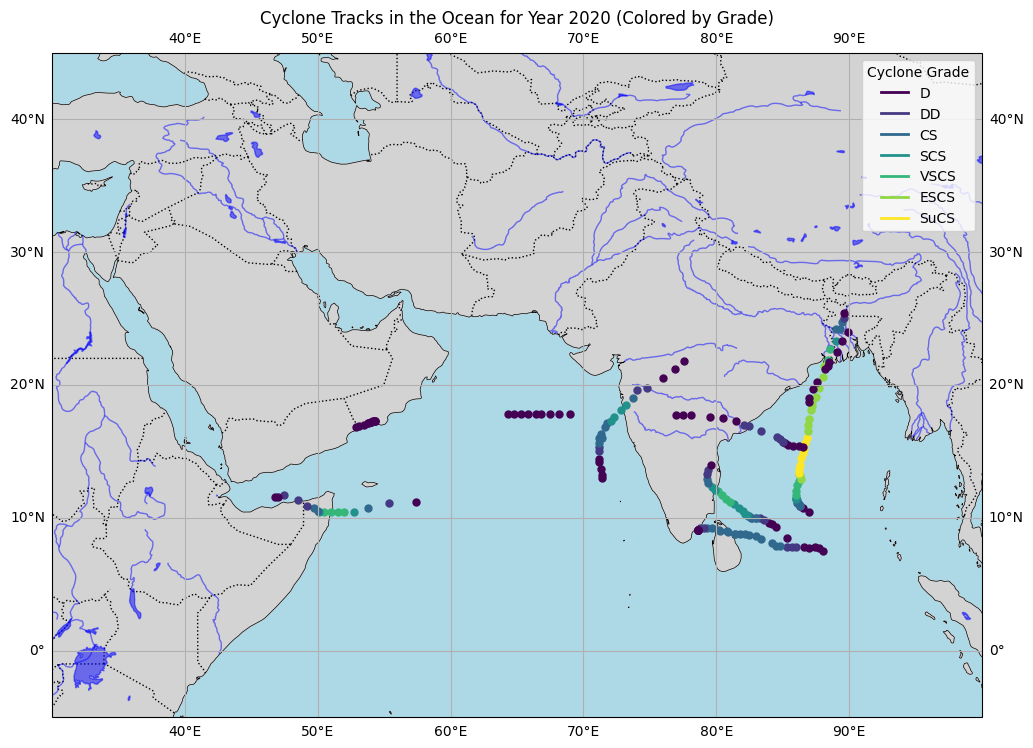

In [ ]:
cmap = cm.get_cmap('viridis', len(grade_order))  # Create colormap

# Create color dictionary based on the 'viridis' colormap
grade_colors = {grade: cmap(i) for i, grade in enumerate(grade_order)}

# Initialize map
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.LAKES, color="blue", alpha=0.5)
ax.add_feature(cfeature.RIVERS, color="blue",alpha=0.5)

# Get unique cyclone names
unique_cyclones = df_2020['Name'].unique()

# Plot tracks with color grading
for cyclone_name in unique_cyclones:
    cyclone_data = df_2020[df_2020['Name'] == cyclone_name]
    for _, row in cyclone_data.iterrows():
        grade = row['Grade']
        color = grade_colors.get(grade, 'gray')  # Default to gray if grade is missing
        plt.plot(row['Longitude'], row['Latitude'],
                 color=color, marker='o', markersize=5, linewidth=2, linestyle='-',
                 transform=ccrs.PlateCarree())

# Add gridlines and title
plt.title("Cyclone Tracks in the Ocean for Year 2020 (Colored by Grade)")
ax.gridlines(draw_labels=True)

# Add legend for grades
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=2, label=grade)
                   for grade, color in grade_colors.items()]
plt.legend(handles=legend_elements, loc='best', title="Cyclone Grade")

# Map extent
ax.set_extent([30, 100, -5, 45], crs=ccrs.PlateCarree())

plt.show()


<ipython-input-185-14362be3e527>:1: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

/usr/local/lib/python3.10/dist-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



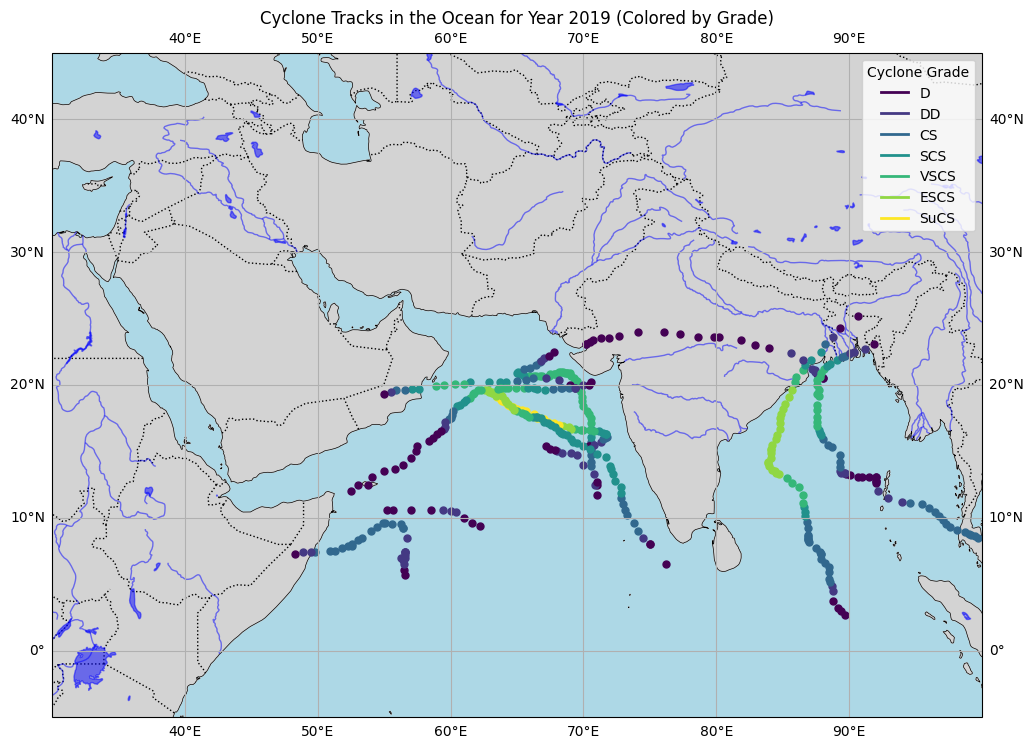

In [ ]:
cmap = cm.get_cmap('viridis', len(grade_order))  # Create colormap

# Create color dictionary based on the 'viridis' colormap
grade_colors = {grade: cmap(i) for i, grade in enumerate(grade_order)}

# Initialize map
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.LAKES, color="blue", alpha=0.5)
ax.add_feature(cfeature.RIVERS, color="blue",alpha=0.5)

# Get unique cyclone names
unique_cyclones = df_2019['Name'].unique()

# Plot tracks with color grading
for cyclone_name in unique_cyclones:
    cyclone_data = df_2019[df_2019['Name'] == cyclone_name]
    for _, row in cyclone_data.iterrows():
        grade = row['Grade']
        color = grade_colors.get(grade, 'gray')  # Default to gray if grade is missing
        plt.plot(row['Longitude'], row['Latitude'],
                 color=color, marker='o', markersize=5, linewidth=2, linestyle='-',
                 transform=ccrs.PlateCarree())

# Add gridlines and title
plt.title("Cyclone Tracks in the Ocean for Year 2019 (Colored by Grade)")
ax.gridlines(draw_labels=True)

# Add legend for grades
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=2, label=grade)
                   for grade, color in grade_colors.items()]
plt.legend(handles=legend_elements, loc='best', title="Cyclone Grade")

# Map extent
ax.set_extent([30, 100, -5, 45], crs=ccrs.PlateCarree())

plt.show()


<ipython-input-186-fbca5f7f2c52>:1: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

/usr/local/lib/python3.10/dist-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



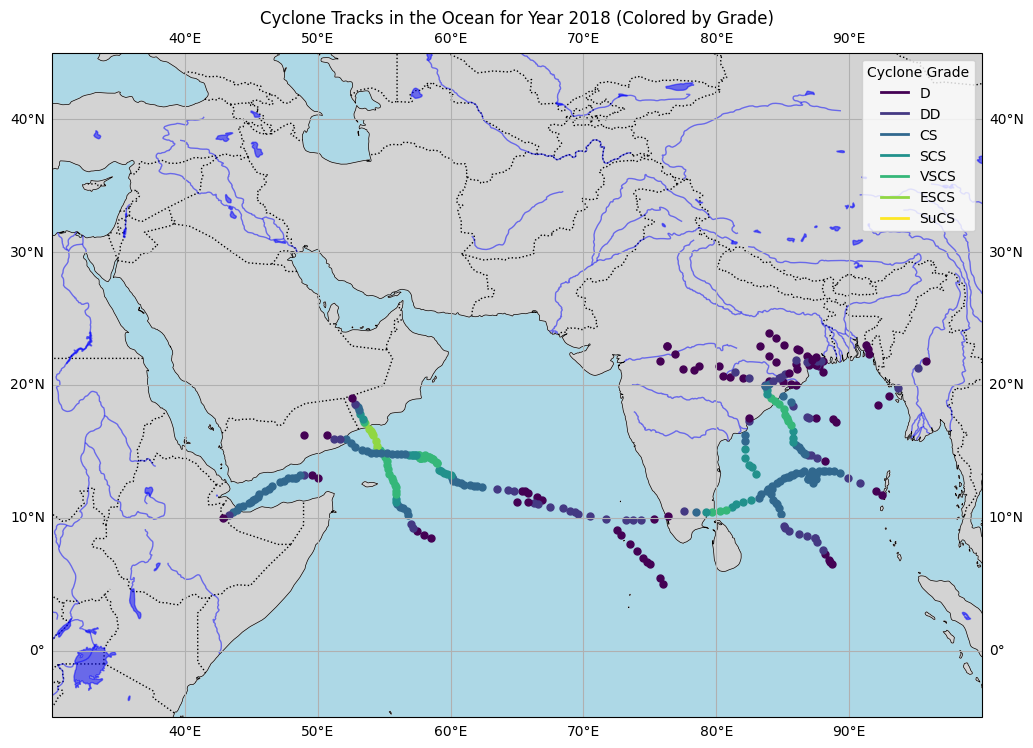

In [ ]:
cmap = cm.get_cmap('viridis', len(grade_order))  # Create colormap

# Create color dictionary based on the 'viridis' colormap
grade_colors = {grade: cmap(i) for i, grade in enumerate(grade_order)}

# Initialize map
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.LAKES, color="blue", alpha=0.5)
ax.add_feature(cfeature.RIVERS, color="blue",alpha=0.5)

# Get unique cyclone names
unique_cyclones = df_2018['Name'].unique()

# Plot tracks with color grading
for cyclone_name in unique_cyclones:
    cyclone_data = df_2018[df_2018['Name'] == cyclone_name]
    for _, row in cyclone_data.iterrows():
        grade = row['Grade']
        color = grade_colors.get(grade, 'gray')  # Default to gray if grade is missing
        # Ensure Longitude and Latitude are numeric
        longitude = pd.to_numeric(row['Longitude'], errors='coerce')
        latitude = pd.to_numeric(row['Latitude'], errors='coerce')

        # Skip plotting if longitude or latitude is invalid
        if pd.isna(longitude) or pd.isna(latitude):
            continue

        plt.plot(longitude, latitude,
                 color=color, marker='o', markersize=5, linewidth=2, linestyle='-',
                 transform=ccrs.PlateCarree())
# Add gridlines and title
plt.title("Cyclone Tracks in the Ocean for Year 2018 (Colored by Grade)")
ax.gridlines(draw_labels=True)

# Add legend for grades
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=2, label=grade)
                   for grade, color in grade_colors.items()]
plt.legend(handles=legend_elements, loc='best', title="Cyclone Grade")

# Map extent
ax.set_extent([30, 100, -5, 45], crs=ccrs.PlateCarree())

plt.show()
